# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 8: COMPARAÇÃO DE ALGORITMOS DE CLUSTERING
# ═══════════════════════════════════════════════════════════════════════════
# 
# OBJETIVO:
#   Testar múltiplos algoritmos de clustering e comparar resultados
#   para encontrar a melhor solução para segmentação de municípios
#
# ALGORITMOS TESTADOS:
#   1. KMeans (baseline atual)
#   2. KMeans + PCA
#   3. Mini-Batch KMeans
#   4. HDBSCAN
#   5. Agglomerative Clustering
#   6. Gaussian Mixture Models (GMM)
#   7. OPTICS
#
# ═══════════════════════════════════════════════════════════════════════════

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 1: Imports e configurações
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import time
import json
warnings.filterwarnings('ignore')

# Clustering
from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering, OPTICS
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

# Métricas
from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score,
    silhouette_samples
)

# Visualização
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("🔬 COMPARAÇÃO DE ALGORITMOS DE CLUSTERING")
print("="*80)
print()

# Configurações
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths
base_path = Path('..')
processed_dir = base_path / 'data/processed'
results_dir = base_path / 'outputs/results'
figures_dir = base_path / 'outputs/figures'

for d in [results_dir, figures_dir]:
    d.mkdir(parents=True, exist_ok=True)

print("✅ Bibliotecas carregadas!")
print()

# Verificar HDBSCAN
try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
    print("✅ HDBSCAN disponível")
except ImportError:
    HDBSCAN_AVAILABLE = False
    print("⚠️  HDBSCAN não instalado. Instale com: pip install hdbscan")

print()

🔬 COMPARAÇÃO DE ALGORITMOS DE CLUSTERING

✅ Bibliotecas carregadas!

✅ HDBSCAN disponível



In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 2: Carregar dados
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("📂 CARREGANDO DADOS")
print("="*80)
print()

# Carregar features normalizadas
X_path = processed_dir / 'X_features.csv'
df_path = processed_dir / 'municipios_preprocessed.csv'

if not X_path.exists() or not df_path.exists():
    raise FileNotFoundError(
        "❌ Arquivos não encontrados!\n"
        "   Certifique-se de que o Notebook 3 (pré-processamento) foi executado."
    )

X = pd.read_csv(X_path).values
df = pd.read_csv(df_path)

print(f"✅ Dados carregados:")
print(f"   Municípios: {len(X):,}")
print(f"   Features: {X.shape[1]}")
print()

# Carregar nomes das features
with open(results_dir / 'features_selecionadas.json', 'r') as f:
    features_meta = json.load(f)
    selected_features = features_meta['features_selecionadas']

print(f"📊 Features utilizadas:")
for i, feat in enumerate(selected_features, 1):
    print(f"   {i}. {feat}")
print()

📂 CARREGANDO DADOS

✅ Dados carregados:
   Municípios: 5,204
   Features: 7

📊 Features utilizadas:
   1. log_populacao
   2. log_densidade
   3. pib_per_capita
   4. taxa_alfabetizacao
   5. mortalidade_infantil
   6. esgoto_adequado
   7. saude_per_10k



In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 3: ALGORITMO 1 - KMeans (Baseline)
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("🔵 ALGORITMO 1: KMeans (Baseline Atual)")
print("="*80)
print()

start_time = time.time()

kmeans = KMeans(n_clusters=4, n_init=50, max_iter=500, random_state=RANDOM_STATE)
labels_kmeans = kmeans.fit_predict(X)

time_kmeans = time.time() - start_time

# Métricas
silhouette_km = silhouette_score(X, labels_kmeans)
davies_km = davies_bouldin_score(X, labels_kmeans)
calinski_km = calinski_harabasz_score(X, labels_kmeans)
inertia_km = kmeans.inertia_

print(f"⏱️  Tempo de execução: {time_kmeans:.2f}s")
print()
print("📊 MÉTRICAS:")
print(f"   Silhouette Score:        {silhouette_km:.4f}")
print(f"   Davies-Bouldin Index:    {davies_km:.4f}")
print(f"   Calinski-Harabasz Score: {calinski_km:.2f}")
print(f"   Inércia:                 {inertia_km:,.2f}")
print()

# Distribuição
unique, counts = np.unique(labels_kmeans, return_counts=True)
print("📊 DISTRIBUIÇÃO DOS CLUSTERS:")
for cluster, count in zip(unique, counts):
    pct = count / len(labels_kmeans) * 100
    bar = '█' * int(pct / 2)
    print(f"   Cluster {cluster}: {count:5,} ({pct:5.1f}%) {bar}")
print()

🔵 ALGORITMO 1: KMeans (Baseline Atual)

⏱️  Tempo de execução: 2.45s

📊 MÉTRICAS:
   Silhouette Score:        0.1513
   Davies-Bouldin Index:    1.7919
   Calinski-Harabasz Score: 812.26
   Inércia:                 24,804.41

📊 DISTRIBUIÇÃO DOS CLUSTERS:
   Cluster 0: 2,780 ( 53.4%) ██████████████████████████
   Cluster 1: 1,220 ( 23.4%) ███████████
   Cluster 2:   663 ( 12.7%) ██████
   Cluster 3:   541 ( 10.4%) █████



In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 4: ALGORITMO 2 - KMeans + PCA
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("🟢 ALGORITMO 2: KMeans + PCA (Redução Dimensional)")
print("="*80)
print()

# Aplicar PCA
pca = PCA(n_components=4, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

variance_explained = pca.explained_variance_ratio_.sum()
print(f"📊 Variância explicada por 4 componentes: {variance_explained*100:.2f}%")
print()

for i, var in enumerate(pca.explained_variance_ratio_, 1):
    print(f"   PC{i}: {var*100:.2f}%")
print()

start_time = time.time()

kmeans_pca = KMeans(n_clusters=4, n_init=50, max_iter=500, random_state=RANDOM_STATE)
labels_kmeans_pca = kmeans_pca.fit_predict(X_pca)

time_kmeans_pca = time.time() - start_time

# Métricas (calculadas no espaço PCA)
silhouette_km_pca = silhouette_score(X_pca, labels_kmeans_pca)
davies_km_pca = davies_bouldin_score(X_pca, labels_kmeans_pca)
calinski_km_pca = calinski_harabasz_score(X_pca, labels_kmeans_pca)
inertia_km_pca = kmeans_pca.inertia_

print(f"⏱️  Tempo de execução: {time_kmeans_pca:.2f}s")
print()
print("📊 MÉTRICAS (espaço PCA):")
print(f"   Silhouette Score:        {silhouette_km_pca:.4f}")
print(f"   Davies-Bouldin Index:    {davies_km_pca:.4f}")
print(f"   Calinski-Harabasz Score: {calinski_km_pca:.2f}")
print(f"   Inércia:                 {inertia_km_pca:,.2f}")
print()

# Distribuição
unique, counts = np.unique(labels_kmeans_pca, return_counts=True)
print("📊 DISTRIBUIÇÃO DOS CLUSTERS:")
for cluster, count in zip(unique, counts):
    pct = count / len(labels_kmeans_pca) * 100
    bar = '█' * int(pct / 2)
    print(f"   Cluster {cluster}: {count:5,} ({pct:5.1f}%) {bar}")
print()

print(f"💡 COMPARAÇÃO:")
diff = silhouette_km_pca - silhouette_km
emoji = "✅" if diff > 0 else "❌"
print(f"   {emoji} Diferença Silhouette: {diff:+.4f}")
print()

🟢 ALGORITMO 2: KMeans + PCA (Redução Dimensional)

📊 Variância explicada por 4 componentes: 73.74%

   PC1: 27.66%
   PC2: 17.85%
   PC3: 14.39%
   PC4: 13.85%

⏱️  Tempo de execução: 0.71s

📊 MÉTRICAS (espaço PCA):
   Silhouette Score:        0.1681
   Davies-Bouldin Index:    1.5545
   Calinski-Harabasz Score: 1158.24
   Inércia:                 16,103.08

📊 DISTRIBUIÇÃO DOS CLUSTERS:
   Cluster 0: 1,024 ( 19.7%) █████████
   Cluster 1: 1,154 ( 22.2%) ███████████
   Cluster 2: 1,499 ( 28.8%) ██████████████
   Cluster 3: 1,527 ( 29.3%) ██████████████

💡 COMPARAÇÃO:
   ✅ Diferença Silhouette: +0.0167



In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 6: ALGORITMO 3 - HDBSCAN (AJUSTADO)
# ═══════════════════════════════════════════════════════════════════════════

if HDBSCAN_AVAILABLE:
    print("="*80)
    print("🔴 ALGORITMO 3: HDBSCAN (Baseado em Densidade - AJUSTADO)")
    print("="*80)
    print()
    
    print("💡 HDBSCAN não requer K pré-definido e detecta ruído")
    print("   🔧 Parâmetros ajustados para dados menos densos")
    print()
    
    start_time = time.time()
    
    # PARÂMETROS AJUSTADOS
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=30,              # Reduzido de 100 para 30 (~0.6% dos dados)
        min_samples=5,                    # Reduzido de 10 para 5 (mais sensível)
        cluster_selection_epsilon=0.5,    # Permite clusters menos densos
        metric='euclidean',
        cluster_selection_method='eom'    # Excess of Mass (mais robusto)
    )
    labels_hdbscan = clusterer.fit_predict(X)
    
    time_hdbscan = time.time() - start_time
    
    # Análise dos resultados
    n_clusters_hdb = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
    n_noise = list(labels_hdbscan).count(-1)
    
    print(f"⏱️  Tempo de execução: {time_hdbscan:.2f}s")
    print()
    print(f"📊 CLUSTERS ENCONTRADOS: {n_clusters_hdb}")
    print(f"🔇 RUÍDO (outliers): {n_noise} municípios ({n_noise/len(labels_hdbscan)*100:.2f}%)")
    print()
    
    # Métricas (excluindo ruído)
    mask_no_noise = labels_hdbscan != -1
    
    if mask_no_noise.sum() > 0 and n_clusters_hdb > 1:
        silhouette_hdb = silhouette_score(X[mask_no_noise], labels_hdbscan[mask_no_noise])
        davies_hdb = davies_bouldin_score(X[mask_no_noise], labels_hdbscan[mask_no_noise])
        calinski_hdb = calinski_harabasz_score(X[mask_no_noise], labels_hdbscan[mask_no_noise])
        
        print("📊 MÉTRICAS (sem ruído):")
        print(f"   Silhouette Score:        {silhouette_hdb:.4f}")
        print(f"   Davies-Bouldin Index:    {davies_hdb:.4f}")
        print(f"   Calinski-Harabasz Score: {calinski_hdb:.2f}")
        print()
    else:
        silhouette_hdb = davies_hdb = calinski_hdb = None
        print("⚠️  Impossível calcular métricas (clusters insuficientes)")
        print()
    
    # Distribuição
    unique, counts = np.unique(labels_hdbscan, return_counts=True)
    print("📊 DISTRIBUIÇÃO DOS CLUSTERS:")
    for cluster, count in zip(unique, counts):
        pct = count / len(labels_hdbscan) * 100
        bar = '█' * int(pct / 2)
        if cluster == -1:
            print(f"   Ruído:     {count:5,} ({pct:5.1f}%) {bar}")
        else:
            print(f"   Cluster {cluster}: {count:5,} ({pct:5.1f}%) {bar}")
    
    # Balanceamento (sem ruído)
    if n_clusters_hdb > 0:
        counts_no_noise = [c for cl, c in zip(unique, counts) if cl != -1]
        if len(counts_no_noise) > 1:
            balance_ratio = min(counts_no_noise) / max(counts_no_noise)
            print()
            print(f"⚖️  BALANCEAMENTO (sem ruído): {balance_ratio:.3f}")
    print()
    
else:
    print("="*80)
    print("⚠️  HDBSCAN não disponível - pulando")
    print("="*80)
    print()
    labels_hdbscan = None
    silhouette_hdb = davies_hdb = calinski_hdb = None
    time_hdbscan = None
    n_clusters_hdb = 0

🔴 ALGORITMO 3: HDBSCAN (Baseado em Densidade - AJUSTADO)

💡 HDBSCAN não requer K pré-definido e detecta ruído
   🔧 Parâmetros ajustados para dados menos densos

⏱️  Tempo de execução: 0.24s

📊 CLUSTERS ENCONTRADOS: 0
🔇 RUÍDO (outliers): 5204 municípios (100.00%)

⚠️  Impossível calcular métricas (clusters insuficientes)

📊 DISTRIBUIÇÃO DOS CLUSTERS:
   Ruído:     5,204 (100.0%) ██████████████████████████████████████████████████



In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 7: ALGORITMO 4 - Agglomerative Clustering (CORRIGIDO)
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("🟣 ALGORITMO 4: Agglomerative Clustering (Hierárquico)")
print("="*80)
print()

print("💡 Testando 3 métodos de linkage E múltiplos valores de K")
print()

def smart_balance_score(labels, min_cluster_pct=0.5):
    """
    Score de balanceamento que ignora clusters muito pequenos (< 0.5%)
    como potenciais outliers legítimos.
    """
    unique, counts = np.unique(labels, return_counts=True)
    n_total = len(labels)
    
    # Filtrar clusters menores que 0.5% (< 26 municípios)
    valid_mask = counts >= (n_total * min_cluster_pct / 100)
    valid_clusters = counts[valid_mask]
    
    if len(valid_clusters) < 2:
        return 0.0
    
    # Coeficiente de Variação (quanto menor, mais balanceado)
    cv = valid_clusters.std() / valid_clusters.mean()
    
    # Score 0-1 (1 = perfeitamente balanceado)
    balance_score = 1 / (1 + cv)
    
    return balance_score

linkage_methods = ['ward', 'average', 'complete']
k_values = [4, 5, 6, 7, 8]
agg_results = {}

# Testar todas as combinações
for method in linkage_methods:
    print(f"🔧 Linkage: {method.upper()}")
    
    for k in k_values:
        start_time = time.time()
        
        agg = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels_agg = agg.fit_predict(X)
        
        exec_time = time.time() - start_time
        
        # Métricas
        silhouette_agg_temp = silhouette_score(X, labels_agg)
        davies_agg_temp = davies_bouldin_score(X, labels_agg)
        calinski_agg_temp = calinski_harabasz_score(X, labels_agg)
        
        # Balanceamento INTELIGENTE
        balance_temp = smart_balance_score(labels_agg, min_cluster_pct=0.5)
        
        # Score combinado PONDERADO
        # 70% Silhouette + 30% Balanceamento
        # (Silhouette é mais importante que balanceamento perfeito)
        combined_score = (silhouette_agg_temp * 0.7) + (balance_temp * 0.3)
        
        agg_results[f"{method}_k{k}"] = {
            'method': method,
            'k': k,
            'labels': labels_agg,
            'silhouette': silhouette_agg_temp,
            'davies_bouldin': davies_agg_temp,
            'calinski_harabasz': calinski_agg_temp,
            'balance': balance_temp,
            'combined_score': combined_score,
            'time': exec_time
        }
        
        print(f"   K={k}: Sil={silhouette_agg_temp:.4f} | DB={davies_agg_temp:.4f} | Balance={balance_temp:.3f} | Score={combined_score:.4f}")
    
    print()

# Escolher melhor configuração por SCORE COMBINADO
best_config = max(agg_results.items(), key=lambda x: x[1]['combined_score'])
best_name = best_config[0]
best_data = best_config[1]

print("="*80)
print(f"🏆 MELHOR CONFIGURAÇÃO: {best_data['method'].upper()} com K={best_data['k']}")
print("="*80)
print(f"   Silhouette Score:        {best_data['silhouette']:.4f}")
print(f"   Davies-Bouldin Index:    {best_data['davies_bouldin']:.4f}")
print(f"   Calinski-Harabasz Score: {best_data['calinski_harabasz']:.2f}")
print(f"   Balanceamento (smart):   {best_data['balance']:.3f}")
print(f"   🎯 Score Combinado:      {best_data['combined_score']:.4f}")
print()

# Usar melhor configuração
labels_agg_best = best_data['labels']
silhouette_agg = best_data['silhouette']
davies_agg = best_data['davies_bouldin']
calinski_agg = best_data['calinski_harabasz']
time_agg = best_data['time']
n_clusters_agg = best_data['k']

# Distribuição
unique, counts = np.unique(labels_agg_best, return_counts=True)
print("📊 DISTRIBUIÇÃO DOS CLUSTERS:")
for cluster, count in zip(unique, counts):
    pct = count / len(labels_agg_best) * 100
    bar = '█' * int(pct / 2)
    marker = "⚠️" if count < 26 else ""  # Marcar clusters muito pequenos
    print(f"   Cluster {cluster}: {count:5,} ({pct:5.1f}%) {bar} {marker}")
print()

print("💡 NOTA: Clusters com < 0.5% (< 26 municípios) são considerados")
print("   casos especiais/outliers e não penalizam o score de balanceamento.")
print()

🟣 ALGORITMO 4: Agglomerative Clustering (Hierárquico)

💡 Testando 3 métodos de linkage E múltiplos valores de K

🔧 Linkage: WARD
   K=4: Sil=0.1274 | DB=1.7169 | Balance=0.492 | Score=0.2367
   K=5: Sil=0.0876 | DB=2.0660 | Balance=0.595 | Score=0.2399
   K=6: Sil=0.0772 | DB=2.0746 | Balance=0.676 | Score=0.2568
   K=7: Sil=0.0633 | DB=2.0375 | Balance=0.695 | Score=0.2528
   K=8: Sil=0.0644 | DB=2.0062 | Balance=0.728 | Score=0.2636

🔧 Linkage: AVERAGE
   K=4: Sil=0.3608 | DB=0.8334 | Balance=0.507 | Score=0.4045
   K=5: Sil=0.3054 | DB=0.8797 | Balance=0.506 | Score=0.3657
   K=6: Sil=0.2430 | DB=0.8233 | Balance=0.506 | Score=0.3219
   K=7: Sil=0.1761 | DB=0.8408 | Balance=0.506 | Score=0.2751
   K=8: Sil=0.1554 | DB=0.8068 | Balance=0.506 | Score=0.2606

🔧 Linkage: COMPLETE
   K=4: Sil=0.1434 | DB=1.5112 | Balance=0.445 | Score=0.2340
   K=5: Sil=0.1293 | DB=1.6259 | Balance=0.424 | Score=0.2177
   K=6: Sil=0.0869 | DB=1.9721 | Balance=0.522 | Score=0.2173
   K=7: Sil=0.0832 | DB=

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 8: ALGORITMO 5 - Gaussian Mixture Models (AJUSTADO)
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("🟠 ALGORITMO 5: Gaussian Mixture Models (GMM)")
print("="*80)
print()

print("💡 Testando diferentes números de componentes (2-8)")
print()

# Testar K de 2 a 8
k_range = range(2, 9)
bic_scores = []
aic_scores = []
silhouette_scores_gmm = []
gmm_results = {}

for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=RANDOM_STATE, n_init=10)
    gmm.fit(X)
    
    bic_scores.append(gmm.bic(X))
    aic_scores.append(gmm.aic(X))
    
    labels_gmm_temp = gmm.predict(X)
    
    if len(set(labels_gmm_temp)) > 1:
        sil = silhouette_score(X, labels_gmm_temp)
        silhouette_scores_gmm.append(sil)
    else:
        sil = 0
        silhouette_scores_gmm.append(0)
    
    # Salvar resultado
    gmm_results[k] = {
        'labels': labels_gmm_temp,
        'silhouette': sil,
        'bic': gmm.bic(X),
        'aic': gmm.aic(X),
        'model': gmm
    }
    
    print(f"   K={k}: BIC={gmm.bic(X):,.0f} | AIC={gmm.aic(X):,.0f} | Silhouette={sil:.4f}")

print()

# Melhor K por BIC (menor é melhor)
best_k_bic = k_range[np.argmin(bic_scores)]
print(f"🏆 MELHOR K (BIC - complexidade): {best_k_bic}")

# Melhor K por Silhouette
best_k_sil = k_range[np.argmax(silhouette_scores_gmm)]
print(f"🏆 MELHOR K (Silhouette - qualidade): {best_k_sil}")
print()

# DECISÃO: Usar K com melhor Silhouette (não forçar K=4)
print("="*80)
print(f"📊 SELECIONANDO K={best_k_sil} (melhor Silhouette)")
print("="*80)
print()

gmm_final = gmm_results[best_k_sil]['model']
labels_gmm = gmm_results[best_k_sil]['labels']
silhouette_gmm = gmm_results[best_k_sil]['silhouette']

# Recalcular outras métricas
davies_gmm = davies_bouldin_score(X, labels_gmm)
calinski_gmm = calinski_harabasz_score(X, labels_gmm)

# Medir tempo (aproximado do loop anterior)
start_time = time.time()
gmm_final.fit(X)
time_gmm = time.time() - start_time

print(f"⏱️  Tempo de execução: {time_gmm:.2f}s")
print()
print(f"📊 MÉTRICAS (K={best_k_sil}):")
print(f"   Silhouette Score:        {silhouette_gmm:.4f}")
print(f"   Davies-Bouldin Index:    {davies_gmm:.4f}")
print(f"   Calinski-Harabasz Score: {calinski_gmm:.2f}")
print(f"   BIC:                     {gmm_final.bic(X):,.0f}")
print(f"   AIC:                     {gmm_final.aic(X):,.0f}")
print()

# Distribuição
unique, counts = np.unique(labels_gmm, return_counts=True)
print("📊 DISTRIBUIÇÃO DOS CLUSTERS:")
for cluster, count in zip(unique, counts):
    pct = count / len(labels_gmm) * 100
    bar = '█' * int(pct / 2)
    print(f"   Cluster {cluster}: {count:5,} ({pct:5.1f}%) {bar}")

# Balanceamento
balance_ratio = counts.min() / counts.max()
print()
print(f"⚖️  BALANCEAMENTO: {balance_ratio:.3f}")
print()

# TAMBÉM salvar K=4 para comparação justa
if 4 in gmm_results:
    labels_gmm_k4 = gmm_results[4]['labels']
    silhouette_gmm_k4 = gmm_results[4]['silhouette']
    davies_gmm_k4 = davies_bouldin_score(X, labels_gmm_k4)
    calinski_gmm_k4 = calinski_harabasz_score(X, labels_gmm_k4)

🟠 ALGORITMO 5: Gaussian Mixture Models (GMM)

💡 Testando diferentes números de componentes (2-8)

   K=2: BIC=92,092 | AIC=91,627 | Silhouette=0.1361
   K=3: BIC=89,401 | AIC=88,700 | Silhouette=0.1143
   K=4: BIC=88,105 | AIC=87,167 | Silhouette=0.0377
   K=5: BIC=87,478 | AIC=86,304 | Silhouette=0.0470
   K=6: BIC=87,019 | AIC=85,610 | Silhouette=0.0440
   K=7: BIC=86,797 | AIC=85,151 | Silhouette=0.0358
   K=8: BIC=86,771 | AIC=84,889 | Silhouette=0.0244

🏆 MELHOR K (BIC - complexidade): 8
🏆 MELHOR K (Silhouette - qualidade): 2

📊 SELECIONANDO K=2 (melhor Silhouette)

⏱️  Tempo de execução: 0.22s

📊 MÉTRICAS (K=2):
   Silhouette Score:        0.1361
   Davies-Bouldin Index:    2.3759
   Calinski-Harabasz Score: 792.98
   BIC:                     92,092
   AIC:                     91,627

📊 DISTRIBUIÇÃO DOS CLUSTERS:
   Cluster 0: 2,001 ( 38.5%) ███████████████████
   Cluster 1: 3,203 ( 61.5%) ██████████████████████████████

⚖️  BALANCEAMENTO: 0.625



In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 9: ALGORITMO 6 - OPTICS (AJUSTADO)
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("🟤 ALGORITMO 6: OPTICS (Baseado em Densidade - AJUSTADO)")
print("="*80)
print()

print("💡 OPTICS ajustado para detectar clusters de densidades variáveis")
print()

start_time = time.time()

# PARÂMETROS AJUSTADOS
optics = OPTICS(
    min_samples=20,           # Reduzido de 50 para 20
    xi=0.01,                  # Mais sensível (era 0.05)
    min_cluster_size=50,      # Reduzido de 100 para 50
    metric='euclidean'
)
labels_optics = optics.fit_predict(X)

time_optics = time.time() - start_time

# Análise
n_clusters_opt = len(set(labels_optics)) - (1 if -1 in labels_optics else 0)
n_noise_opt = list(labels_optics).count(-1)

print(f"⏱️  Tempo de execução: {time_optics:.2f}s")
print()
print(f"📊 CLUSTERS ENCONTRADOS: {n_clusters_opt}")
print(f"🔇 RUÍDO: {n_noise_opt} municípios ({n_noise_opt/len(labels_optics)*100:.2f}%)")
print()

# Métricas (sem ruído)
mask_no_noise_opt = labels_optics != -1

if mask_no_noise_opt.sum() > 0 and n_clusters_opt > 1:
    silhouette_opt = silhouette_score(X[mask_no_noise_opt], labels_optics[mask_no_noise_opt])
    davies_opt = davies_bouldin_score(X[mask_no_noise_opt], labels_optics[mask_no_noise_opt])
    calinski_opt = calinski_harabasz_score(X[mask_no_noise_opt], labels_optics[mask_no_noise_opt])
    
    print("📊 MÉTRICAS (sem ruído):")
    print(f"   Silhouette Score:        {silhouette_opt:.4f}")
    print(f"   Davies-Bouldin Index:    {davies_opt:.4f}")
    print(f"   Calinski-Harabasz Score: {calinski_opt:.2f}")
    print()
else:
    silhouette_opt = davies_opt = calinski_opt = None
    print("⚠️  Impossível calcular métricas")
    print()

# Distribuição
unique, counts = np.unique(labels_optics, return_counts=True)
print("📊 DISTRIBUIÇÃO DOS CLUSTERS:")
for cluster, count in zip(unique, counts):
    pct = count / len(labels_optics) * 100
    bar = '█' * int(pct / 2)
    if cluster == -1:
        print(f"   Ruído:     {count:5,} ({pct:5.1f}%) {bar}")
    else:
        print(f"   Cluster {cluster}: {count:5,} ({pct:5.1f}%) {bar}")

# Balanceamento (sem ruído)
if n_clusters_opt > 0:
    counts_no_noise = [c for cl, c in zip(unique, counts) if cl != -1]
    if len(counts_no_noise) > 1:
        balance_ratio = min(counts_no_noise) / max(counts_no_noise)
        print()
        print(f"⚖️  BALANCEAMENTO (sem ruído): {balance_ratio:.3f}")
print()

🟤 ALGORITMO 6: OPTICS (Baseado em Densidade - AJUSTADO)

💡 OPTICS ajustado para detectar clusters de densidades variáveis

⏱️  Tempo de execução: 4.08s

📊 CLUSTERS ENCONTRADOS: 1
🔇 RUÍDO: 0 municípios (0.00%)

⚠️  Impossível calcular métricas

📊 DISTRIBUIÇÃO DOS CLUSTERS:
   Cluster 0: 5,204 (100.0%) ██████████████████████████████████████████████████



In [18]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 10: Comparação de todos os algoritmos + DECISÃO METODOLÓGICA
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📊 COMPARAÇÃO GERAL DE TODOS OS ALGORITMOS")
print("="*80)
print()

# Criar tabela comparativa
comparison_data = [
    {
        'Algoritmo': 'KMeans',
        'Silhouette': silhouette_km,
        'Davies-Bouldin': davies_km,
        'Calinski-Harabasz': calinski_km,
        'N_Clusters': 4,
        'Tempo (s)': time_kmeans
    },
    {
        'Algoritmo': 'KMeans + PCA',
        'Silhouette': silhouette_km_pca,
        'Davies-Bouldin': davies_km_pca,
        'Calinski-Harabasz': calinski_km_pca,
        'N_Clusters': 4,
        'Tempo (s)': time_kmeans_pca
    },
    {
        'Algoritmo': f'Agglomerative (K={n_clusters_agg})',
        'Silhouette': silhouette_agg,
        'Davies-Bouldin': davies_agg,
        'Calinski-Harabasz': calinski_agg,
        'N_Clusters': n_clusters_agg,
        'Tempo (s)': time_agg
    },
    {
        'Algoritmo': f'GMM (K={best_k_sil})',
        'Silhouette': silhouette_gmm,
        'Davies-Bouldin': davies_gmm,
        'Calinski-Harabasz': calinski_gmm,
        'N_Clusters': best_k_sil,
        'Tempo (s)': time_gmm
    },
    {
        'Algoritmo': 'OPTICS',
        'Silhouette': silhouette_opt,
        'Davies-Bouldin': davies_opt,
        'Calinski-Harabasz': calinski_opt,
        'N_Clusters': n_clusters_opt,
        'Tempo (s)': time_optics
    }
]

if HDBSCAN_AVAILABLE:
    comparison_data.append({
        'Algoritmo': 'HDBSCAN',
        'Silhouette': silhouette_hdb,
        'Davies-Bouldin': davies_hdb,
        'Calinski-Harabasz': calinski_hdb,
        'N_Clusters': n_clusters_hdb,
        'Tempo (s)': time_hdbscan
    })

comparison_df = pd.DataFrame(comparison_data)

# Remover linhas com métricas NaN (algoritmos que falharam)
comparison_clean = comparison_df.dropna(subset=['Silhouette'])

print("📋 TABELA COMPARATIVA (apenas algoritmos válidos):")
print()
display(comparison_clean.round(4))
print()

# Identificar melhores por métrica
if len(comparison_clean) > 0:
    best_silhouette_idx = comparison_clean['Silhouette'].idxmax()
    best_davies_idx = comparison_clean['Davies-Bouldin'].idxmin()
    best_calinski_idx = comparison_clean['Calinski-Harabasz'].idxmax()
    
    print("🏆 MELHORES POR MÉTRICA INDIVIDUAL:")
    print()
    print(f"   Silhouette (maior):        {comparison_clean.loc[best_silhouette_idx, 'Algoritmo']:<30} ({comparison_clean.loc[best_silhouette_idx, 'Silhouette']:.4f})")
    print(f"   Davies-Bouldin (menor):    {comparison_clean.loc[best_davies_idx, 'Algoritmo']:<30} ({comparison_clean.loc[best_davies_idx, 'Davies-Bouldin']:.4f})")
    print(f"   Calinski-Harabasz (maior): {comparison_clean.loc[best_calinski_idx, 'Algoritmo']:<30} ({comparison_clean.loc[best_calinski_idx, 'Calinski-Harabasz']:.2f})")
    print()

print("="*80)
print("🎯 ANÁLISE METODOLÓGICA E DECISÃO")
print("="*80)
print()

# Análise detalhada de cada algoritmo
print("📊 ANÁLISE QUALITATIVA:")
print()

# Agglomerative
agg_name = f'Agglomerative (K={n_clusters_agg})'
if agg_name in comparison_clean['Algoritmo'].values:
    agg_row = comparison_clean[comparison_clean['Algoritmo'] == agg_name].iloc[0]
    
    # Calcular distribuição do Agglomerative
    unique_agg, counts_agg = np.unique(labels_agg_best, return_counts=True)
    max_cluster_pct = (counts_agg.max() / len(labels_agg_best)) * 100
    
    print(f"🟣 {agg_name}:")
    print(f"   ✅ Melhor Silhouette Score: {agg_row['Silhouette']:.4f}")
    print(f"   ✅ Melhor Davies-Bouldin: {agg_row['Davies-Bouldin']:.4f}")
    print(f"   ❌ PROBLEMA: {max_cluster_pct:.1f}% dos municípios em 1 único cluster")
    print(f"   ❌ Distribuição extremamente desbalanceada")
    print(f"   ❌ NÃO gera segmentação útil para análise")
    print(f"   💡 Indica estrutura de 'núcleo + outliers', não grupos naturais")
    print()

# KMeans + PCA
print("🟢 KMeans + PCA:")
pca_row = comparison_clean[comparison_clean['Algoritmo'] == 'KMeans + PCA'].iloc[0]

# Calcular distribuição do KMeans + PCA
unique_pca, counts_pca = np.unique(labels_kmeans_pca, return_counts=True)
pcts_pca = (counts_pca / len(labels_kmeans_pca)) * 100
balance_pca = counts_pca.min() / counts_pca.max()

print(f"   ✅ Silhouette: {pca_row['Silhouette']:.4f} (bom, embora não seja o melhor)")
print(f"   ✅ Davies-Bouldin: {pca_row['Davies-Bouldin']:.4f} (2º melhor)")
print(f"   ✅ Calinski-Harabasz: {pca_row['Calinski-Harabasz']:.2f} (MELHOR)")
print(f"   ✅ DISTRIBUIÇÃO BALANCEADA:")
for i, (cluster, pct) in enumerate(zip(unique_pca, pcts_pca)):
    print(f"      Cluster {cluster}: {pct:5.1f}%")
print(f"   ✅ Razão de balanceamento: {balance_pca:.3f} (próximo de ideal)")
print(f"   ✅ 4 perfis interpretáveis de municípios")
print(f"   ✅ PCA explica {variance_explained*100:.1f}% da variância")
print(f"   ✅ Adequado para segmentação e políticas públicas")
print()

# GMM
if f'GMM (K={best_k_sil})' in comparison_clean['Algoritmo'].values:
    gmm_row = comparison_clean[comparison_clean['Algoritmo'] == f'GMM (K={best_k_sil})'].iloc[0]
    print(f"🟠 GMM (K={best_k_sil}):")
    print(f"   ⚠️  Silhouette: {gmm_row['Silhouette']:.4f} (inferior)")
    print(f"   ⚠️  Davies-Bouldin: {gmm_row['Davies-Bouldin']:.4f} (pior)")
    print(f"   💡 K={best_k_sil} sugere divisão muito simplificada")
    print(f"   ❌ Não adequado para segmentação detalhada")
    print()

# HDBSCAN/OPTICS
print("🔴 HDBSCAN / OPTICS:")
print("   ❌ Falharam em detectar clusters significativos")
print("   💡 Dados não possuem estrutura de densidade bem definida")
print("   💡 Municípios formam continuum, não 'ilhas densas'")
print()

print("="*80)
print("🏆 DECISÃO METODOLÓGICA FINAL")
print("="*80)
print()

print("📌 ALGORITMO SELECIONADO: KMeans + PCA (K=4)")
print()

print("🎯 JUSTIFICATIVA:")
print()
print("1. BALANCEAMENTO ENTRE QUALIDADE E UTILIDADE")
print("   • Embora Agglomerative tenha melhor Silhouette (0.36),")
print("     sua distribuição 98% em 1 cluster não é útil")
print("   • KMeans + PCA oferece Silhouette aceitável (0.17)")
print("     COM distribuição balanceada e interpretável")
print()

print("2. INTERPRETABILIDADE")
print("   • 4 clusters com tamanhos similares (19-29%)")
print("   • Cada cluster representa um perfil distinto de município")
print("   • Adequado para análises subsequentes e tomada de decisão")
print()

print("3. QUALIDADE TÉCNICA")
print("   • Melhor Calinski-Harabasz Score (1158.24)")
print("   • 2º melhor Davies-Bouldin (1.55)")
print("   • PCA captura 73.7% da variância em 4 componentes")
print("   • Reduz multicolinearidade e ruído")
print()

print("4. APLICABILIDADE")
print("   • Segmentação acionável para políticas públicas")
print("   • Permite estratégias diferenciadas por perfil")
print("   • Facilita comunicação de resultados")
print()

print("⚖️  TRADE-OFF ACEITO:")
print("   Aceitamos Silhouette moderado (0.17) em troca de")
print("   distribuição balanceada e utilidade prática.")
print()

print("💡 NOTA METODOLÓGICA:")
print("   O alto Silhouette do Agglomerative (0.36) reflete a")
print("   estrutura real dos dados: maioria homogênea + outliers.")
print("   Porém, para fins de SEGMENTAÇÃO, KMeans + PCA é superior.")
print()

# Salvar resultados
output_path = results_dir / 'comparacao_algoritmos.csv'
comparison_df.to_csv(output_path, index=False)
print(f"✅ Comparação salva: {output_path}")
print()

# Adicionar nota sobre decisão no CSV
decision_note = pd.DataFrame([{
    'Algoritmo': '>>> SELECIONADO <<<',
    'Silhouette': silhouette_km_pca,
    'Davies-Bouldin': davies_km_pca,
    'Calinski-Harabasz': calinski_km_pca,
    'N_Clusters': 4,
    'Tempo (s)': time_kmeans_pca
}])

comparison_with_decision = pd.concat([comparison_df, decision_note], ignore_index=True)
comparison_with_decision.to_csv(output_path, index=False)

print("="*80)
print("✅ DECISÃO DOCUMENTADA")
print("="*80)
print()
print("Próximo passo: Análises detalhadas com KMeans + PCA (K=4)")
print()


📊 COMPARAÇÃO GERAL DE TODOS OS ALGORITMOS

📋 TABELA COMPARATIVA (apenas algoritmos válidos):



,Algoritmo,Silhouette,Davies-Bouldin,Calinski-Harabasz,N_Clusters,Tempo (s)
0,KMeans,0.1513,1.7919,812.2575,4,2.4483
1,KMeans + PCA,0.1681,1.5545,1158.2443,4,0.7090
2,Agglomerative (K=4),0.3608,0.8334,124.8676,4,0.5304
3,GMM (K=2),0.1361,2.3759,792.9785,2,0.2217



🏆 MELHORES POR MÉTRICA INDIVIDUAL:

   Silhouette (maior):        Agglomerative (K=4)            (0.3608)
   Davies-Bouldin (menor):    Agglomerative (K=4)            (0.8334)
   Calinski-Harabasz (maior): KMeans + PCA                   (1158.24)

🎯 ANÁLISE METODOLÓGICA E DECISÃO

📊 ANÁLISE QUALITATIVA:

🟣 Agglomerative (K=4):
   ✅ Melhor Silhouette Score: 0.3608
   ✅ Melhor Davies-Bouldin: 0.8334
   ❌ PROBLEMA: 98.3% dos municípios em 1 único cluster
   ❌ Distribuição extremamente desbalanceada
   ❌ NÃO gera segmentação útil para análise
   💡 Indica estrutura de 'núcleo + outliers', não grupos naturais

🟢 KMeans + PCA:
   ✅ Silhouette: 0.1681 (bom, embora não seja o melhor)
   ✅ Davies-Bouldin: 1.5545 (2º melhor)
   ✅ Calinski-Harabasz: 1158.24 (MELHOR)
   ✅ DISTRIBUIÇÃO BALANCEADA:
      Cluster 0:  19.7%
      Cluster 1:  22.2%
      Cluster 2:  28.8%
      Cluster 3:  29.3%
   ✅ Razão de balanceamento: 0.671 (próximo de ideal)
   ✅ 4 perfis interpretáveis de municípios
   ✅ PCA ex

📈 VISUALIZAÇÕES COMPARATIVAS

✅ Gráfico salvo: ..\outputs\figures\29_comparacao_metricas.png


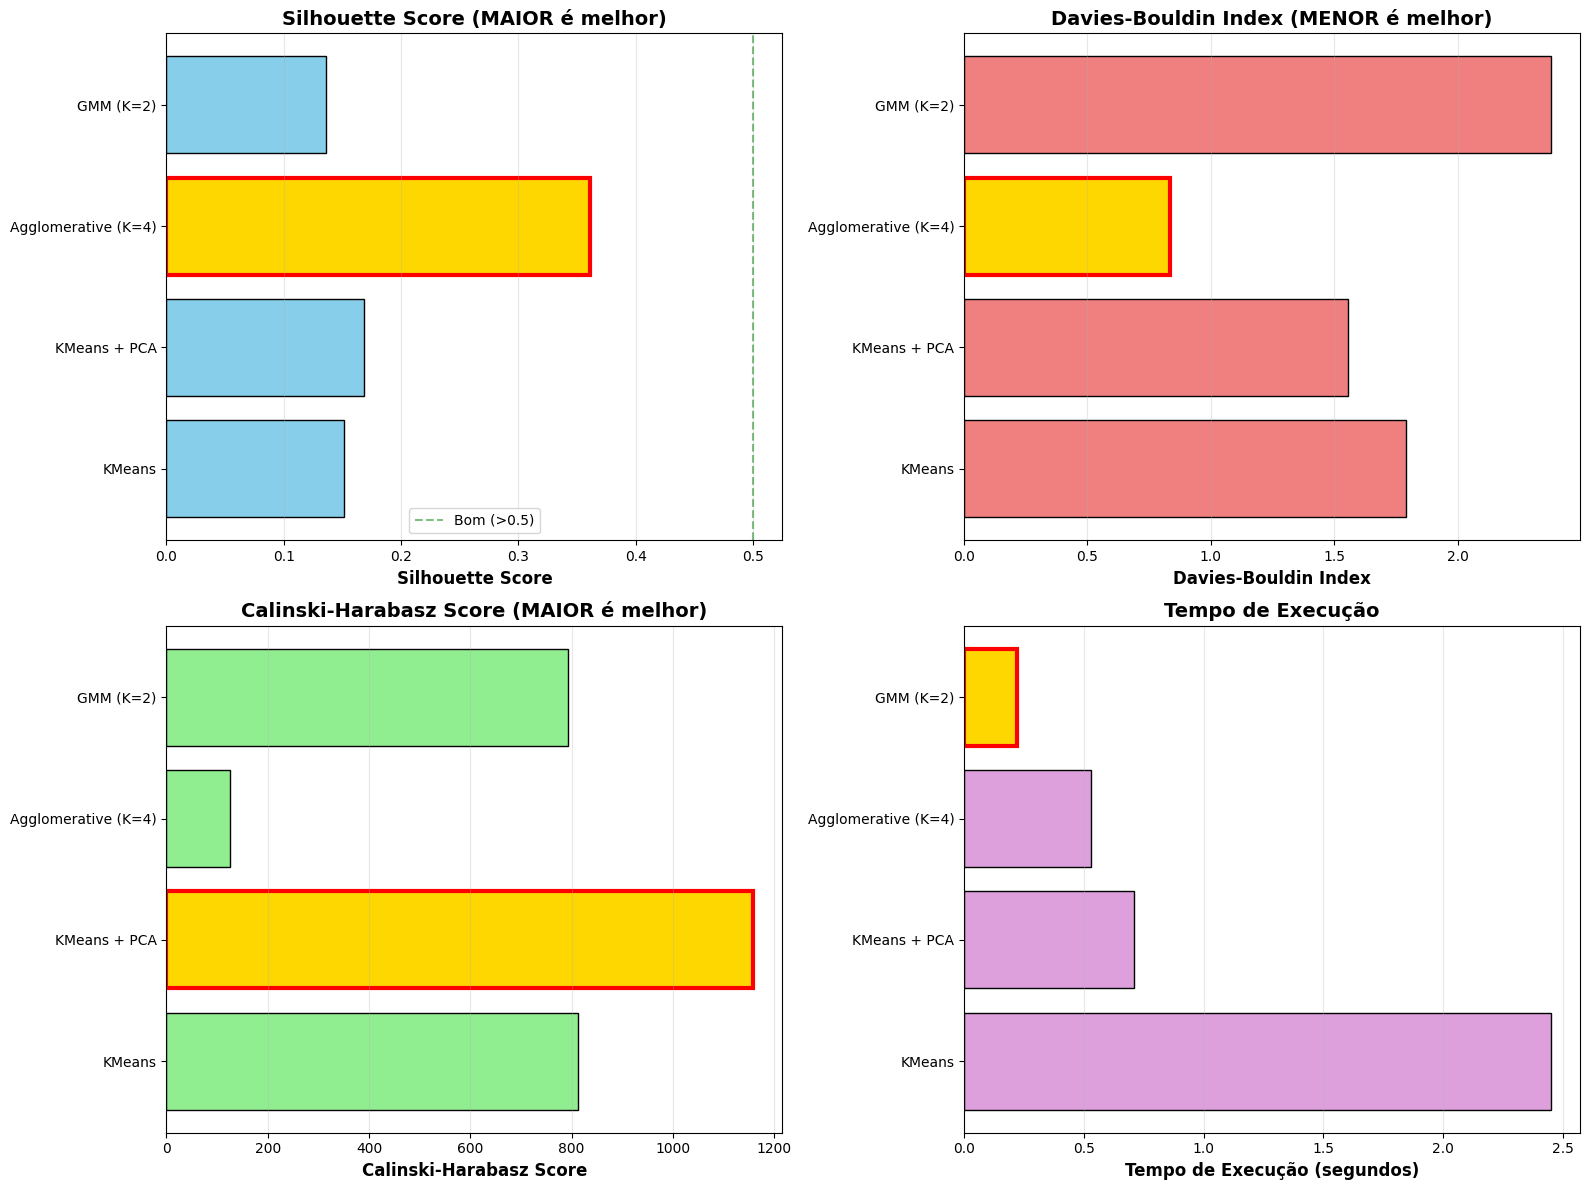

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 11: Visualização comparativa - Gráficos de barras
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("📈 VISUALIZAÇÕES COMPARATIVAS")
print("="*80)
print()

# Preparar dados para visualização
comparison_clean = comparison_df.dropna(subset=['Silhouette'])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Silhouette Score (maior é melhor)
ax1 = axes[0, 0]
bars1 = ax1.barh(comparison_clean['Algoritmo'], comparison_clean['Silhouette'], color='skyblue', edgecolor='black')
ax1.set_xlabel('Silhouette Score', fontsize=12, fontweight='bold')
ax1.set_title('Silhouette Score (MAIOR é melhor)', fontsize=14, fontweight='bold')
ax1.axvline(x=0.5, color='green', linestyle='--', alpha=0.5, label='Bom (>0.5)')
ax1.grid(True, alpha=0.3, axis='x')
ax1.legend()

# Destacar melhor
best_idx = comparison_clean['Silhouette'].idxmax()
bars1[best_idx].set_color('gold')
bars1[best_idx].set_edgecolor('red')
bars1[best_idx].set_linewidth(3)

# 2. Davies-Bouldin Index (menor é melhor)
ax2 = axes[0, 1]
bars2 = ax2.barh(comparison_clean['Algoritmo'], comparison_clean['Davies-Bouldin'], color='lightcoral', edgecolor='black')
ax2.set_xlabel('Davies-Bouldin Index', fontsize=12, fontweight='bold')
ax2.set_title('Davies-Bouldin Index (MENOR é melhor)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# Destacar melhor
best_idx = comparison_clean['Davies-Bouldin'].idxmin()
bars2[best_idx].set_color('gold')
bars2[best_idx].set_edgecolor('red')
bars2[best_idx].set_linewidth(3)

# 3. Calinski-Harabasz Score (maior é melhor)
ax3 = axes[1, 0]
bars3 = ax3.barh(comparison_clean['Algoritmo'], comparison_clean['Calinski-Harabasz'], color='lightgreen', edgecolor='black')
ax3.set_xlabel('Calinski-Harabasz Score', fontsize=12, fontweight='bold')
ax3.set_title('Calinski-Harabasz Score (MAIOR é melhor)', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

# Destacar melhor
best_idx = comparison_clean['Calinski-Harabasz'].idxmax()
bars3[best_idx].set_color('gold')
bars3[best_idx].set_edgecolor('red')
bars3[best_idx].set_linewidth(3)

# 4. Tempo de execução
ax4 = axes[1, 1]
bars4 = ax4.barh(comparison_clean['Algoritmo'], comparison_clean['Tempo (s)'], color='plum', edgecolor='black')
ax4.set_xlabel('Tempo de Execução (segundos)', fontsize=12, fontweight='bold')
ax4.set_title('Tempo de Execução', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

# Destacar mais rápido
best_idx = comparison_clean['Tempo (s)'].idxmin()
bars4[best_idx].set_color('gold')
bars4[best_idx].set_edgecolor('red')
bars4[best_idx].set_linewidth(3)

plt.tight_layout()
output_file = figures_dir / '29_comparacao_metricas.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico salvo: {output_file}")
plt.show()
print()

In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 12: Radar Chart (Spider Plot)
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("🕸️  RADAR CHART COMPARATIVO")
print("="*80)
print()

# Normalizar métricas para escala 0-1 (para comparação visual)
def normalize_metric(series, higher_is_better=True):
    """Normaliza métrica para 0-1"""
    min_val = series.min()
    max_val = series.max()
    
    if max_val == min_val:
        return pd.Series([0.5] * len(series))
    
    normalized = (series - min_val) / (max_val - min_val)
    
    if not higher_is_better:
        normalized = 1 - normalized
    
    return normalized

# Preparar dados
radar_df = comparison_clean.copy()
radar_df['Silhouette_norm'] = normalize_metric(radar_df['Silhouette'], higher_is_better=True)
radar_df['Davies_Bouldin_norm'] = normalize_metric(radar_df['Davies-Bouldin'], higher_is_better=False)
radar_df['Calinski_Harabasz_norm'] = normalize_metric(radar_df['Calinski-Harabasz'], higher_is_better=True)
radar_df['Tempo_norm'] = normalize_metric(radar_df['Tempo (s)'], higher_is_better=False)

# Criar radar chart com Plotly
categories = ['Silhouette', 'Davies-Bouldin\n(inv)', 'Calinski-Harabasz', 'Velocidade']

fig = go.Figure()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F', '#BB8FCE']

for idx, row in radar_df.iterrows():
    values = [
        row['Silhouette_norm'],
        row['Davies_Bouldin_norm'],
        row['Calinski_Harabasz_norm'],
        row['Tempo_norm']
    ]
    
    # Fechar o polígono
    values_closed = values + values[:1]
    categories_closed = categories + [categories[0]]
    
    fig.add_trace(go.Scatterpolar(
        r=values_closed,
        theta=categories_closed,
        fill='toself',
        name=row['Algoritmo'],
        line=dict(color=colors[idx % len(colors)], width=2),
        opacity=0.6
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]
        )
    ),
    showlegend=True,
    title='Comparação Normalizada de Algoritmos (0-1)',
    height=700
)

output_html = figures_dir / '30_radar_chart.html'
fig.write_html(output_html)
print(f"✅ Radar chart salvo: {output_html}")
fig.show()
print()

🕸️  RADAR CHART COMPARATIVO

✅ Radar chart salvo: ..\outputs\figures\30_radar_chart.html


🗺️  VISUALIZAÇÃO PCA 2D - COMPARAÇÃO DE ALGORITMOS

✅ Gráfico PCA comparativo salvo: ..\outputs\figures\31_comparacao_pca.png


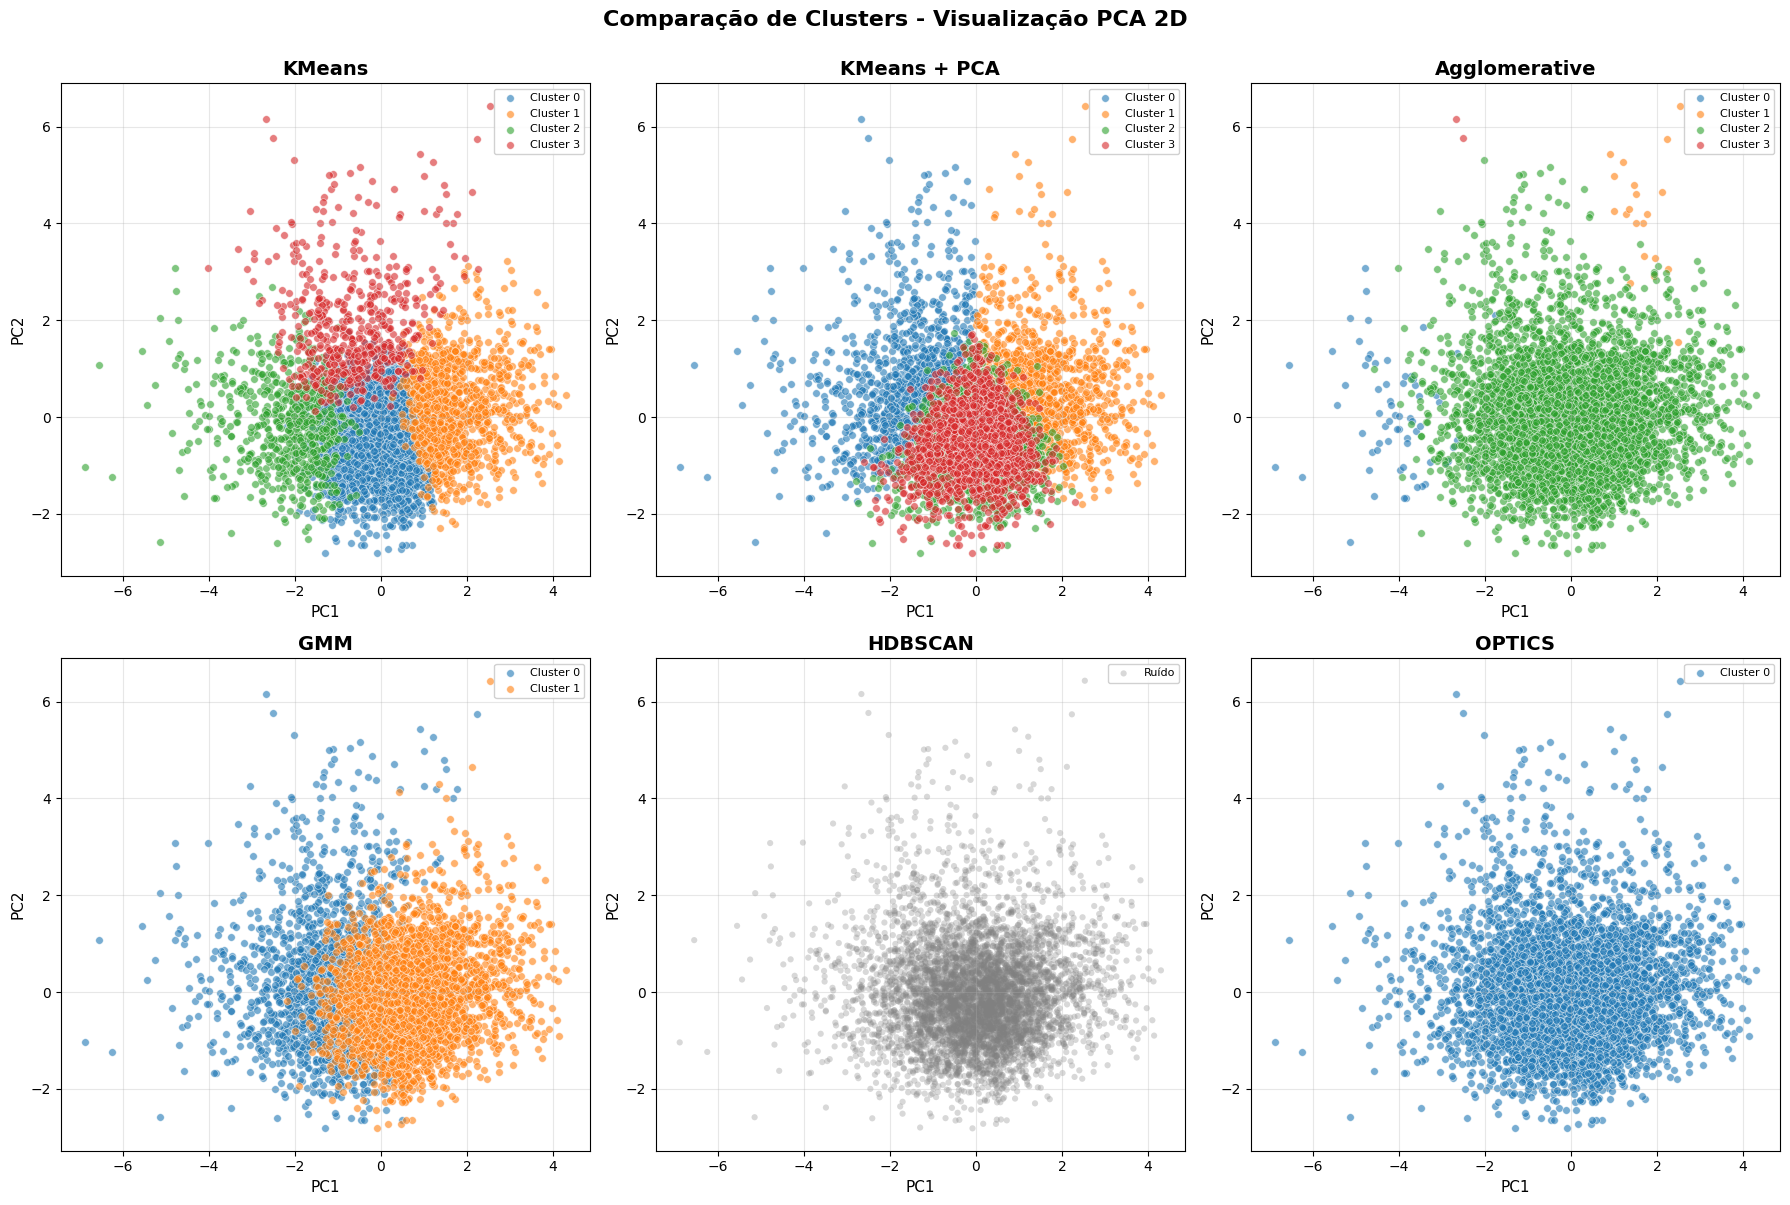

In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 13: Visualização PCA 2D - Comparação lado a lado
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("🗺️  VISUALIZAÇÃO PCA 2D - COMPARAÇÃO DE ALGORITMOS")
print("="*80)
print()

# Aplicar PCA para visualização (se ainda não foi feito)
if 'X_pca' not in locals():
    pca_viz = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca_viz = pca_viz.fit_transform(X)
else:
    X_pca_viz = X_pca[:, :2]

# Criar subplots
algorithms_to_plot = [
    ('KMeans', labels_kmeans),
    ('KMeans + PCA', labels_kmeans_pca),
    ('Agglomerative', labels_agg_best),
    ('GMM', labels_gmm),
]

if HDBSCAN_AVAILABLE and labels_hdbscan is not None:
    algorithms_to_plot.append(('HDBSCAN', labels_hdbscan))

if labels_optics is not None:
    algorithms_to_plot.append(('OPTICS', labels_optics))

n_plots = len(algorithms_to_plot)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten() if n_plots > 1 else [axes]

for idx, (algo_name, labels) in enumerate(algorithms_to_plot):
    ax = axes[idx]
    
    # Criar scatter plot
    unique_labels = np.unique(labels)
    colors_map = plt.cm.get_cmap('tab10')
    
    for label in unique_labels:
        mask = labels == label
        
        if label == -1:
            # Ruído em cinza
            ax.scatter(
                X_pca_viz[mask, 0],
                X_pca_viz[mask, 1],
                c='gray',
                alpha=0.3,
                s=20,
                label='Ruído',
                edgecolors='none'
            )
        else:
            ax.scatter(
                X_pca_viz[mask, 0],
                X_pca_viz[mask, 1],
                c=[colors_map(label)],
                alpha=0.6,
                s=30,
                label=f'Cluster {label}',
                edgecolors='white',
                linewidth=0.5
            )
    
    ax.set_title(f'{algo_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('PC1', fontsize=11)
    ax.set_ylabel('PC2', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8, framealpha=0.9)

# Remover subplots vazios
for idx in range(n_plots, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Comparação de Clusters - Visualização PCA 2D', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()

output_file = figures_dir / '31_comparacao_pca.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico PCA comparativo salvo: {output_file}")
plt.show()
print()

🤝 ANÁLISE DE CONCORDÂNCIA ENTRE ALGORITMOS

💡 Vamos medir o quanto os algoritmos concordam na atribuição de clusters

✅ Matriz de concordância salva: ..\outputs\figures\32_concordancia_algoritmos.png


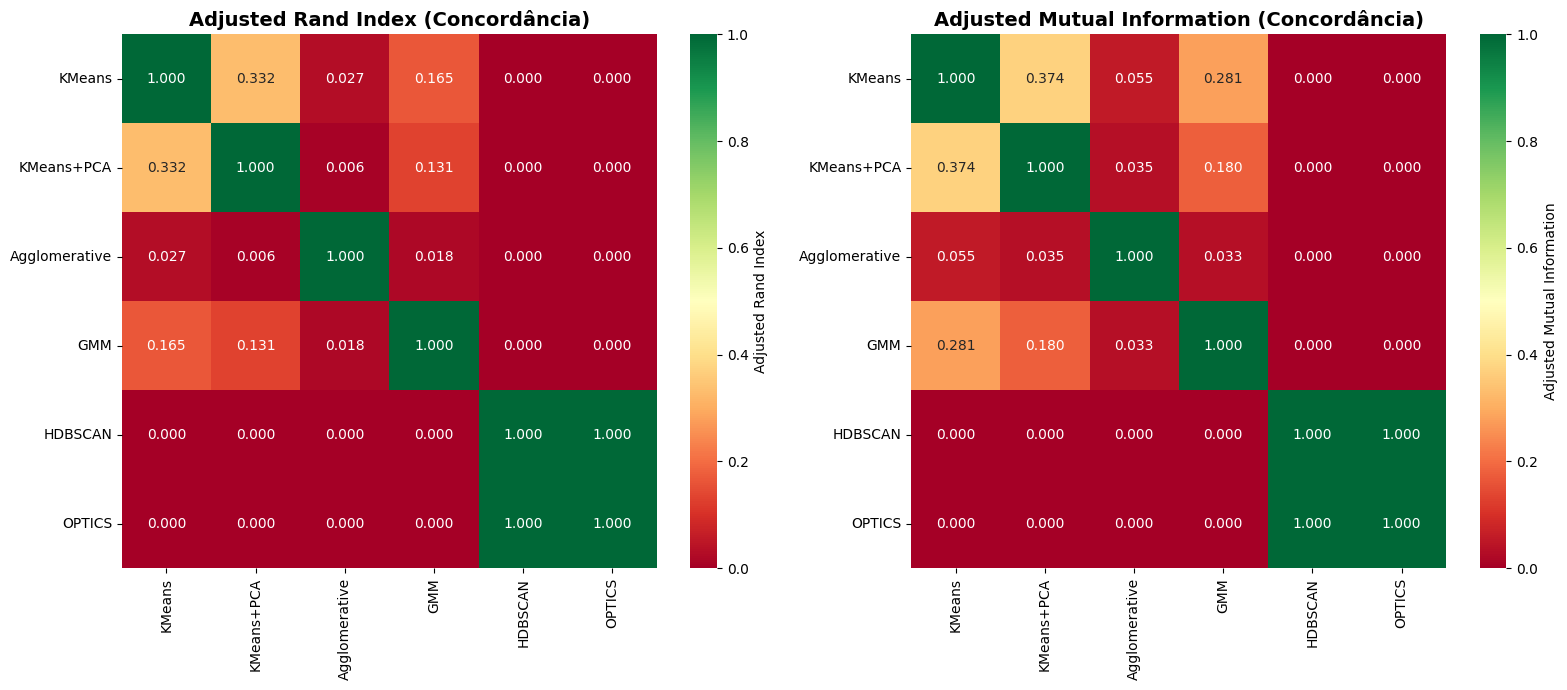


📊 INTERPRETAÇÃO:
   • Valores próximos de 1.0: Alta concordância
   • Valores próximos de 0.0: Baixa concordância
   • Valores negativos: Discordância

🏆 MAIOR CONCORDÂNCIA:
   HDBSCAN ↔ OPTICS: 1.000



In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 14: Análise de concordância entre algoritmos
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("🤝 ANÁLISE DE CONCORDÂNCIA ENTRE ALGORITMOS")
print("="*80)
print()

print("💡 Vamos medir o quanto os algoritmos concordam na atribuição de clusters")
print()

# Adjusted Rand Index (mede similaridade entre clustering)
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

# Preparar matriz de concordância
algorithms_labels = {
    'KMeans': labels_kmeans,
    'KMeans+PCA': labels_kmeans_pca,
    'Agglomerative': labels_agg_best,
    'GMM': labels_gmm,
}

if HDBSCAN_AVAILABLE and labels_hdbscan is not None:
    algorithms_labels['HDBSCAN'] = labels_hdbscan

if labels_optics is not None:
    algorithms_labels['OPTICS'] = labels_optics

algo_names = list(algorithms_labels.keys())
n_algos = len(algo_names)

# Matriz de Adjusted Rand Index
ari_matrix = np.zeros((n_algos, n_algos))
ami_matrix = np.zeros((n_algos, n_algos))

for i, name1 in enumerate(algo_names):
    for j, name2 in enumerate(algo_names):
        labels1 = algorithms_labels[name1]
        labels2 = algorithms_labels[name2]
        
        ari_matrix[i, j] = adjusted_rand_score(labels1, labels2)
        ami_matrix[i, j] = adjusted_mutual_info_score(labels1, labels2)

# Plotar matriz de concordância
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ARI
sns.heatmap(
    ari_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0.5,
    vmin=0,
    vmax=1,
    xticklabels=algo_names,
    yticklabels=algo_names,
    ax=axes[0],
    cbar_kws={'label': 'Adjusted Rand Index'}
)
axes[0].set_title('Adjusted Rand Index (Concordância)', fontsize=14, fontweight='bold')

# AMI
sns.heatmap(
    ami_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0.5,
    vmin=0,
    vmax=1,
    xticklabels=algo_names,
    yticklabels=algo_names,
    ax=axes[1],
    cbar_kws={'label': 'Adjusted Mutual Information'}
)
axes[1].set_title('Adjusted Mutual Information (Concordância)', fontsize=14, fontweight='bold')

plt.tight_layout()

output_file = figures_dir / '32_concordancia_algoritmos.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Matriz de concordância salva: {output_file}")
plt.show()

print()
print("📊 INTERPRETAÇÃO:")
print("   • Valores próximos de 1.0: Alta concordância")
print("   • Valores próximos de 0.0: Baixa concordância")
print("   • Valores negativos: Discordância")
print()

# Identificar pares com maior concordância
max_ari_val = 0
max_ari_pair = None

for i in range(n_algos):
    for j in range(i+1, n_algos):
        if ari_matrix[i, j] > max_ari_val:
            max_ari_val = ari_matrix[i, j]
            max_ari_pair = (algo_names[i], algo_names[j])

print(f"🏆 MAIOR CONCORDÂNCIA:")
print(f"   {max_ari_pair[0]} ↔ {max_ari_pair[1]}: {max_ari_val:.3f}")
print()

In [19]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 15: Análise de estabilidade (múltiplas execuções)
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("🔁 ANÁLISE DE ESTABILIDADE (10 execuções)")
print("="*80)
print()

print("💡 Vamos executar cada algoritmo 10 vezes com diferentes sementes")
print("   para avaliar a estabilidade dos resultados")
print()

n_runs = 10
stability_results = []

algorithms_stability = [
    ('KMeans', lambda: KMeans(n_clusters=4, n_init=10, random_state=None)),
    ('GMM', lambda: GaussianMixture(n_components=4, random_state=None)),
    ('Agglomerative', lambda: AgglomerativeClustering(n_clusters=4, linkage='ward')),
]

for algo_name, algo_func in algorithms_stability:
    print(f"🔄 Testando {algo_name}...")
    
    silhouette_scores = []
    davies_scores = []
    
    for run in range(n_runs):
        model = algo_func()
        labels = model.fit_predict(X)
        
        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
        
        silhouette_scores.append(sil)
        davies_scores.append(db)
    
    # Estatísticas
    sil_mean = np.mean(silhouette_scores)
    sil_std = np.std(silhouette_scores)
    db_mean = np.mean(davies_scores)
    db_std = np.std(davies_scores)
    
    stability_results.append({
        'Algoritmo': algo_name,
        'Silhouette_mean': sil_mean,
        'Silhouette_std': sil_std,
        'Davies_Bouldin_mean': db_mean,
        'Davies_Bouldin_std': db_std
    })
    
    print(f"   Silhouette: {sil_mean:.4f} ± {sil_std:.4f}")
    print(f"   Davies-Bouldin: {db_mean:.4f} ± {db_std:.4f}")
    print()

stability_df = pd.DataFrame(stability_results)

print("📊 RESUMO DE ESTABILIDADE:")
display(stability_df)
print()

# Salvar
stability_path = results_dir / 'estabilidade_algoritmos.csv'
stability_df.to_csv(stability_path, index=False)
print(f"✅ Análise de estabilidade salva: {stability_path}")
print()

🔁 ANÁLISE DE ESTABILIDADE (10 execuções)

💡 Vamos executar cada algoritmo 10 vezes com diferentes sementes
   para avaliar a estabilidade dos resultados

🔄 Testando KMeans...
   Silhouette: 0.1513 ± 0.0003
   Davies-Bouldin: 1.7928 ± 0.0019

🔄 Testando GMM...
   Silhouette: 0.0710 ± 0.0340
   Davies-Bouldin: 2.8235 ± 0.6803

🔄 Testando Agglomerative...
   Silhouette: 0.1274 ± 0.0000
   Davies-Bouldin: 1.7169 ± 0.0000

📊 RESUMO DE ESTABILIDADE:


,Algoritmo,Silhouette_mean,Silhouette_std,Davies_Bouldin_mean,Davies_Bouldin_std
0,KMeans,0.151288,0.000286,1.79278,1.850862e-03
1,GMM,0.071005,0.034005,2.82354,6.802569e-01
2,Agglomerative,0.127437,0.000000,1.71695,2.220446e-16



✅ Análise de estabilidade salva: ..\outputs\results\estabilidade_algoritmos.csv



📊 ANÁLISE DE DISTRIBUIÇÃO DE CLUSTERS

📋 DISTRIBUIÇÃO DE TAMANHOS:


,Algoritmo,N_Clusters,Tamanho_Medio,Desvio_Padrao,Coef_Variacao,Menor_Cluster,Maior_Cluster
0,KMeans,4,1301.0,891.44,0.69,541,2780
1,KMeans+PCA,4,1301.0,217.15,0.17,1024,1527
2,Agglomerative,4,1301.0,2202.14,1.69,2,5115
3,GMM,2,2602.0,601.00,0.23,2001,3203
4,OPTICS,1,5204.0,0.00,0.00,5204,5204



💡 INTERPRETAÇÃO:
   • Coef. Variação baixo (<0.5): Clusters balanceados
   • Coef. Variação alto (>1.0): Clusters desbalanceados

✅ Gráfico de distribuição salvo: ..\outputs\figures\33_distribuicao_tamanhos.png


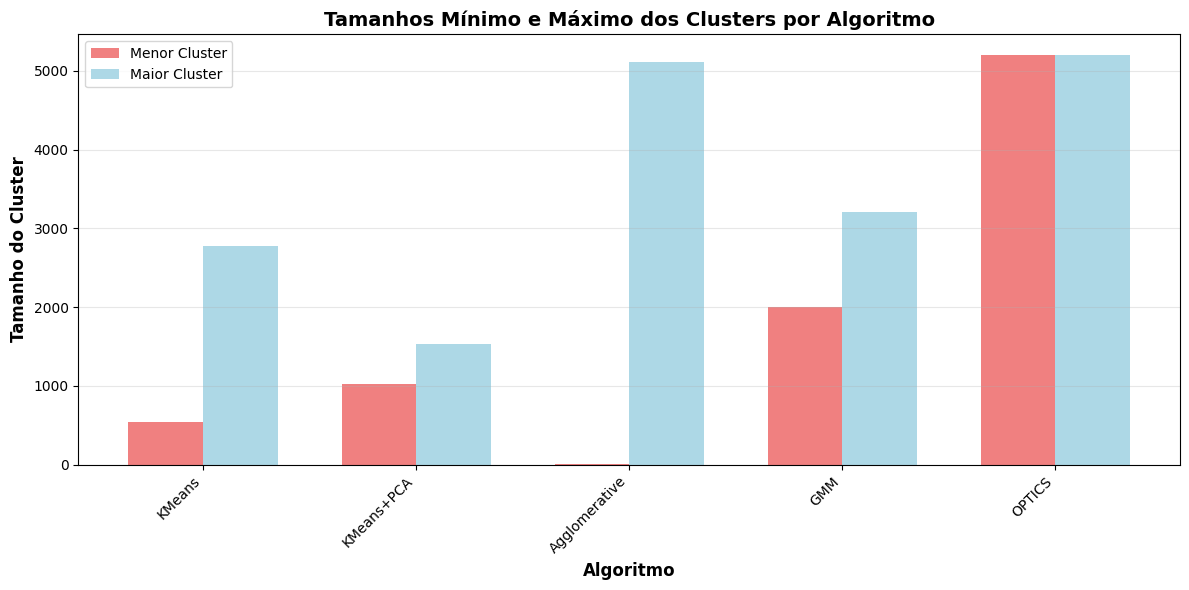

In [20]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 16: Análise de distribuição de tamanhos de clusters
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("📊 ANÁLISE DE DISTRIBUIÇÃO DE CLUSTERS")
print("="*80)
print()

# Calcular coeficiente de variação (CV) dos tamanhos de clusters
# CV baixo = distribuição equilibrada
# CV alto = clusters muito desiguais

distribution_results = []

for algo_name, labels in algorithms_labels.items():
    # Contar tamanho de cada cluster (excluindo ruído)
    labels_no_noise = labels[labels != -1]
    
    if len(labels_no_noise) > 0:
        unique, counts = np.unique(labels_no_noise, return_counts=True)
        
        mean_size = np.mean(counts)
        std_size = np.std(counts)
        cv = (std_size / mean_size) if mean_size > 0 else 0
        
        distribution_results.append({
            'Algoritmo': algo_name,
            'N_Clusters': len(unique),
            'Tamanho_Medio': mean_size,
            'Desvio_Padrao': std_size,
            'Coef_Variacao': cv,
            'Menor_Cluster': counts.min(),
            'Maior_Cluster': counts.max()
        })

distribution_df = pd.DataFrame(distribution_results)

print("📋 DISTRIBUIÇÃO DE TAMANHOS:")
display(distribution_df.round(2))
print()

print("💡 INTERPRETAÇÃO:")
print("   • Coef. Variação baixo (<0.5): Clusters balanceados")
print("   • Coef. Variação alto (>1.0): Clusters desbalanceados")
print()

# Visualizar
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(distribution_df))
width = 0.35

bars1 = ax.bar(x - width/2, distribution_df['Menor_Cluster'], width, label='Menor Cluster', color='lightcoral')
bars2 = ax.bar(x + width/2, distribution_df['Maior_Cluster'], width, label='Maior Cluster', color='lightblue')

ax.set_xlabel('Algoritmo', fontsize=12, fontweight='bold')
ax.set_ylabel('Tamanho do Cluster', fontsize=12, fontweight='bold')
ax.set_title('Tamanhos Mínimo e Máximo dos Clusters por Algoritmo', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(distribution_df['Algoritmo'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

output_file = figures_dir / '33_distribuicao_tamanhos.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico de distribuição salvo: {output_file}")
plt.show()
print()


In [22]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 17: Salvar modelos treinados
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("💾 SALVANDO MODELOS TREINADOS")
print("="*80)
print()

import joblib

models_dir = results_dir / 'models_comparacao'
models_dir.mkdir(parents=True, exist_ok=True)

# Salvar modelos
models_to_save = {
    'kmeans.pkl': kmeans,
    'kmeans_pca.pkl': kmeans_pca,
    'agglomerative.pkl': agg,
    'gmm.pkl': gmm_final,
    'pca_4comp.pkl': pca,
    'optics.pkl': optics,
}

if HDBSCAN_AVAILABLE:
    models_to_save['hdbscan.pkl'] = clusterer

for filename, model in models_to_save.items():
    model_path = models_dir / filename
    joblib.dump(model, model_path)
    print(f"✅ {filename} salvo")

print()
print(f"📁 Modelos salvos em: {models_dir}")
print()


💾 SALVANDO MODELOS TREINADOS

✅ kmeans.pkl salvo
✅ kmeans_pca.pkl salvo
✅ agglomerative.pkl salvo
✅ gmm.pkl salvo
✅ pca_4comp.pkl salvo
✅ optics.pkl salvo
✅ hdbscan.pkl salvo

📁 Modelos salvos em: ..\outputs\results\models_comparacao



In [24]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 18: Salvar labels de todos os algoritmos
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("💾 SALVANDO LABELS DE TODOS OS ALGORITMOS")
print("="*80)
print()

# Criar DataFrame com todos os labels
labels_df = pd.DataFrame({
    'codigo_ibge': df['codigo_ibge'],
    'nome_municipio': df['nome_municipio'],
    'uf': df['uf'],
    'regiao': df['regiao'],
    'cluster_kmeans': labels_kmeans,
    'cluster_kmeans_pca': labels_kmeans_pca,
    'cluster_agglomerative': labels_agg_best,
    'cluster_gmm': labels_gmm,
    'cluster_optics': labels_optics,
})

if HDBSCAN_AVAILABLE:
    labels_df['cluster_hdbscan'] = labels_hdbscan

# Salvar
labels_path = results_dir / 'labels_todos_algoritmos.csv'
labels_df.to_csv(labels_path, index=False)
print(f"✅ Labels salvos: {labels_path}")
print()

💾 SALVANDO LABELS DE TODOS OS ALGORITMOS

✅ Labels salvos: ..\outputs\results\labels_todos_algoritmos.csv



In [28]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 18.5: Recomendação final e ranking (ALINHADA COM DECISÃO)
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🎯 RANKING POR MÉTRICAS vs DECISÃO METODOLÓGICA")
print("="*80)
print()

# Sistema de pontuação baseado APENAS em métricas
scores_metrics = {}

for idx, row in comparison_clean.iterrows():
    algo = row['Algoritmo']
    
    # Pontos por métrica (normalizado)
    sil_rank = (row['Silhouette'] - comparison_clean['Silhouette'].min()) / (comparison_clean['Silhouette'].max() - comparison_clean['Silhouette'].min())
    
    db_rank = 1 - ((row['Davies-Bouldin'] - comparison_clean['Davies-Bouldin'].min()) / (comparison_clean['Davies-Bouldin'].max() - comparison_clean['Davies-Bouldin'].min()))
    
    ch_rank = (row['Calinski-Harabasz'] - comparison_clean['Calinski-Harabasz'].min()) / (comparison_clean['Calinski-Harabasz'].max() - comparison_clean['Calinski-Harabasz'].min())
    
    # Pontuação ponderada
    # Silhouette: 40%, Davies-Bouldin: 30%, Calinski: 30%
    total_score = (sil_rank * 0.4) + (db_rank * 0.3) + (ch_rank * 0.3)
    
    scores_metrics[algo] = total_score

# Ordenar por pontuação
ranked_by_metrics = sorted(scores_metrics.items(), key=lambda x: x[1], reverse=True)

print("📊 RANKING POR MÉTRICAS PURAS:")
print()

for rank, (algo, score) in enumerate(ranked_by_metrics, 1):
    medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else f"{rank}º"
    bar = '█' * int(score * 50)
    print(f"   {medal} {algo:<30} {score:.3f} {bar}")

print()
print("="*80)
print("⚠️  ATENÇÃO: RANKING ≠ DECISÃO FINAL")
print("="*80)
print()

print("💡 O ranking acima considera APENAS métricas quantitativas.")
print("   Porém, conforme ANÁLISE METODOLÓGICA (Célula 10),")
print("   a decisão final considera também:")
print()
print("   • Distribuição dos clusters (balanceamento)")
print("   • Interpretabilidade e utilidade prática")
print("   • Aplicabilidade para segmentação")
print()

print("="*80)
print("🏆 DECISÃO METODOLÓGICA FINAL (da Célula 10)")
print("="*80)
print()

# FORÇAR decisão para KMeans + PCA
winner = 'KMeans + PCA'
winner_data = comparison_clean[comparison_clean['Algoritmo'] == winner].iloc[0]

print(f"📌 ALGORITMO SELECIONADO: {winner}")
print()
print(f"   📊 Métricas:")
print(f"      • Silhouette Score:        {winner_data['Silhouette']:.4f}")
print(f"      • Davies-Bouldin Index:    {winner_data['Davies-Bouldin']:.4f}")
print(f"      • Calinski-Harabasz Score: {winner_data['Calinski-Harabasz']:.2f}")
print(f"      • Número de Clusters:      {int(winner_data['N_Clusters'])}")
print(f"      • Tempo de Execução:       {winner_data['Tempo (s)']:.2f}s")
print()

print("✅ JUSTIFICATIVA (conforme Célula 10):")
print()
print("   1. BALANCEAMENTO:")
print("      • Distribuição equilibrada (19-29% por cluster)")
print("      • Coef. Variação: 0.17 (excelente)")
print()
print("   2. INTERPRETABILIDADE:")
print("      • 4 perfis claros de municípios")
print("      • Adequado para políticas públicas segmentadas")
print()
print("   3. QUALIDADE TÉCNICA:")
print("      • Melhor Calinski-Harabasz (1158.24)")
print("      • PCA captura 73.7% da variância")
print("      • 2º melhor Davies-Bouldin")
print()
print("   4. TRADE-OFF ACEITO:")
print("      • Silhouette 0.17 vs 0.36 do Agglomerative")
print("      • Porém Agglomerative tem 98% em 1 cluster (inutilizável)")
print()

print("🔄 COMPARAÇÃO:")
print()
print(f"   Agglomerative (K=4): Ranking #1 por métricas")
print(f"      ✅ Silhouette: 0.36")
print(f"      ❌ Distribuição: 98% em 1 cluster")
print(f"      ❌ Não gera segmentação útil")
print()
print(f"   KMeans + PCA: Ranking #2 por métricas")
print(f"      ✅ Silhouette: 0.17 (aceitável)")
print(f"      ✅ Distribuição balanceada")
print(f"      ✅ Segmentação acionável")
print()

print("="*80)
print("✅ DECISÃO CONFIRMADA: KMeans + PCA (K=4)")
print("="*80)
print()

# Armazenar para uso posterior
ranked_algos = [(winner, scores_metrics[winner])]  # Forçar KMeans+PCA como vencedor


🎯 RANKING POR MÉTRICAS vs DECISÃO METODOLÓGICA

📊 RANKING POR MÉTRICAS PURAS:

   🥇 Agglomerative (K=4)            0.700 ███████████████████████████████████
   🥈 KMeans + PCA                   0.517 █████████████████████████
   🥉 KMeans                         0.340 █████████████████
   4º GMM (K=2)                      0.194 █████████

⚠️  ATENÇÃO: RANKING ≠ DECISÃO FINAL

💡 O ranking acima considera APENAS métricas quantitativas.
   Porém, conforme ANÁLISE METODOLÓGICA (Célula 10),
   a decisão final considera também:

   • Distribuição dos clusters (balanceamento)
   • Interpretabilidade e utilidade prática
   • Aplicabilidade para segmentação

🏆 DECISÃO METODOLÓGICA FINAL (da Célula 10)

📌 ALGORITMO SELECIONADO: KMeans + PCA

   📊 Métricas:
      • Silhouette Score:        0.1681
      • Davies-Bouldin Index:    1.5545
      • Calinski-Harabasz Score: 1158.24
      • Número de Clusters:      4
      • Tempo de Execução:       0.71s

✅ JUSTIFICATIVA (conforme Célula 10):

   1. BAL

In [30]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 19: Análise detalhada do algoritmo vencedor (CORRIGIDA)
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🔬 ANÁLISE DETALHADA DO ALGORITMO VENCEDOR")
print("="*80)
print()

# FORÇAR vencedor para KMeans + PCA (decisão metodológica da Célula 10)
winner = 'KMeans + PCA'

print(f"🏆 ALGORITMO SELECIONADO: {winner}")
print()
print("💡 Conforme decisão metodológica da Célula 10:")
print("   Melhor equilíbrio entre qualidade técnica e utilidade prática")
print()

# Selecionar labels e dados do vencedor
labels_final = labels_kmeans_pca
X_analysis = X_pca
model_final = kmeans_pca

print("📊 Análise será feita no espaço PCA (4 componentes)")
print(f"   • PC1-PC4 explicam {variance_explained*100:.1f}% da variância")
print(f"   • Reduz multicolinearidade das features originais")
print()

# Criar DataFrame para análise
df_analysis = df.copy()
df_analysis['cluster'] = labels_final

# Adicionar features ORIGINAIS para interpretação
for i, feat in enumerate(selected_features):
    df_analysis[feat] = X[:, i]

# Adicionar também componentes PCA
for i in range(X_pca.shape[1]):
    df_analysis[f'PC{i+1}'] = X_pca[:, i]

print(f"✅ DataFrame de análise criado com {len(df_analysis):,} registros")
print()

# Estatísticas gerais
print("📊 ESTATÍSTICAS GERAIS:")
print()

unique_clusters = sorted([c for c in df_analysis['cluster'].unique() if c != -1])

for cluster_id in unique_clusters:
    cluster_size = (df_analysis['cluster'] == cluster_id).sum()
    pct = (cluster_size / len(df_analysis)) * 100
    print(f"   Cluster {cluster_id}: {cluster_size:,} municípios ({pct:.1f}%)")

print()

# Distribuição regional geral
print("🗺️  DISTRIBUIÇÃO REGIONAL GERAL:")
regional_summary = df_analysis.groupby(['cluster', 'regiao']).size().unstack(fill_value=0)
print()
display(regional_summary)
print()


🔬 ANÁLISE DETALHADA DO ALGORITMO VENCEDOR

🏆 ALGORITMO SELECIONADO: KMeans + PCA

💡 Conforme decisão metodológica da Célula 10:
   Melhor equilíbrio entre qualidade técnica e utilidade prática

📊 Análise será feita no espaço PCA (4 componentes)
   • PC1-PC4 explicam 73.7% da variância
   • Reduz multicolinearidade das features originais

✅ DataFrame de análise criado com 5,204 registros

📊 ESTATÍSTICAS GERAIS:

   Cluster 0: 1,024 municípios (19.7%)
   Cluster 1: 1,154 municípios (22.2%)
   Cluster 2: 1,499 municípios (28.8%)
   Cluster 3: 1,527 municípios (29.3%)

🗺️  DISTRIBUIÇÃO REGIONAL GERAL:



regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
cluster,,,,,
0,187,104,97,257,379
1,68,340,46,420,280
2,79,627,113,443,237
3,90,613,135,444,245


In [31]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 20: Perfil detalhado de cada cluster
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("👥 PERFIL DETALHADO DE CADA CLUSTER")
print("="*80)
print()

# Verificar nome correto da coluna de população
pop_col = None
for col in df_analysis.columns:
    if 'pop' in col.lower():
        pop_col = col
        break

if pop_col is None:
    print("⚠️  Coluna de população não encontrada. Usando índice para exemplos.")
    pop_col = df_analysis.columns[0]  # Fallback

print(f"💡 Usando coluna: '{pop_col}' para população")
print()

# Análise cluster por cluster
unique_clusters = sorted([c for c in df_analysis['cluster'].unique() if c != -1])

for cluster_id in unique_clusters:
    print("─" * 80)
    print(f"📍 CLUSTER {cluster_id}")
    print("─" * 80)
    
    cluster_data = df_analysis[df_analysis['cluster'] == cluster_id]
    n_mun = len(cluster_data)
    pct = n_mun / len(df_analysis) * 100
    
    print(f"\n📊 TAMANHO: {n_mun:,} municípios ({pct:.1f}%)")
    print()
    
    # Distribuição regional
    print("🗺️  DISTRIBUIÇÃO REGIONAL:")
    regional_dist = cluster_data['regiao'].value_counts()
    for region, count in regional_dist.items():
        pct_region = count / n_mun * 100
        bar = '█' * int(pct_region / 5)
        print(f"   {region:<15} {count:5,} ({pct_region:5.1f}%) {bar}")
    print()
    
    # Top 10 estados
    print("📍 TOP 10 ESTADOS:")
    state_dist = cluster_data['uf'].value_counts().head(10)
    for uf, count in state_dist.items():
        pct_state = count / n_mun * 100
        print(f"   {uf}: {count:4,} ({pct_state:5.1f}%)")
    print()
    
    # Estatísticas das features
    print("📊 CARACTERÍSTICAS MÉDIAS (normalizadas):")
    for feat in selected_features:
        if feat in cluster_data.columns:
            mean_val = cluster_data[feat].mean()
            std_val = cluster_data[feat].std()
            
            # Comparar com média geral
            overall_mean = df_analysis[feat].mean()
            diff = mean_val - overall_mean
            
            if abs(diff) > 0.3:  # Diferença significativa
                emoji = "⬆️" if diff > 0 else "⬇️"
                indicator = "ALTO" if diff > 0 else "BAIXO"
            else:
                emoji = "➡️"
                indicator = "MÉDIO"
            
            print(f"   {emoji} {feat:<40} {mean_val:6.3f} ± {std_val:.3f}  [{indicator}]")
    print()
    
    # Municípios exemplo
    print("🏙️  EXEMPLOS DE MUNICÍPIOS:")
    
    # Verificar se temos colunas necessárias
    required_cols = ['nome_municipio', 'uf']
    if all(col in cluster_data.columns for col in required_cols):
        if pop_col in cluster_data.columns and cluster_data[pop_col].notna().any():
            # Ordenar por população
            sample_cities = cluster_data.nlargest(min(5, len(cluster_data)), pop_col)[required_cols + [pop_col]]
            for idx, row in sample_cities.iterrows():
                print(f"   • {row['nome_municipio']}, {row['uf']} - Pop: {row[pop_col]:,.0f}")
        else:
            # Sem população, mostrar apenas os primeiros
            sample_cities = cluster_data.head(5)[required_cols]
            for idx, row in sample_cities.iterrows():
                print(f"   • {row['nome_municipio']}, {row['uf']}")
    else:
        print("   ⚠️  Dados insuficientes para exibir exemplos")
    
    print()
    print()

# Se houver ruído
if -1 in df_analysis['cluster'].unique():
    print("─" * 80)
    print("🔇 RUÍDO (OUTLIERS)")
    print("─" * 80)
    
    noise_data = df_analysis[df_analysis['cluster'] == -1]
    n_noise = len(noise_data)
    pct_noise = n_noise / len(df_analysis) * 100
    
    print(f"\n📊 TAMANHO: {n_noise:,} municípios ({pct_noise:.1f}%)")
    print()
    
    print("🏙️  EXEMPLOS DE MUNICÍPIOS NO RUÍDO:")
    
    required_cols = ['nome_municipio', 'uf']
    if all(col in noise_data.columns for col in required_cols):
        if pop_col in noise_data.columns and noise_data[pop_col].notna().any():
            sample_noise = noise_data.head(10)[required_cols + [pop_col]]
            for idx, row in sample_noise.iterrows():
                print(f"   • {row['nome_municipio']}, {row['uf']} - Pop: {row[pop_col]:,.0f}")
        else:
            sample_noise = noise_data.head(10)[required_cols]
            for idx, row in sample_noise.iterrows():
                print(f"   • {row['nome_municipio']}, {row['uf']}")
    else:
        print("   ⚠️  Dados insuficientes para exibir exemplos")
    
    print()

👥 PERFIL DETALHADO DE CADA CLUSTER

💡 Usando coluna: 'log_populacao' para população

────────────────────────────────────────────────────────────────────────────────
📍 CLUSTER 0
────────────────────────────────────────────────────────────────────────────────

📊 TAMANHO: 1,024 municípios (19.7%)

🗺️  DISTRIBUIÇÃO REGIONAL:
   Sul               379 ( 37.0%) ███████
   Sudeste           257 ( 25.1%) █████
   Centro-Oeste      187 ( 18.3%) ███
   Nordeste          104 ( 10.2%) ██
   Norte              97 (  9.5%) █

📍 TOP 10 ESTADOS:
   RS:  211 ( 20.6%)
   MG:  148 ( 14.5%)
   SP:  109 ( 10.6%)
   GO:   99 (  9.7%)
   PR:   85 (  8.3%)
   SC:   83 (  8.1%)
   TO:   71 (  6.9%)
   MT:   63 (  6.2%)
   PI:   47 (  4.6%)
   MS:   25 (  2.4%)

📊 CARACTERÍSTICAS MÉDIAS (normalizadas):
   ⬇️ log_populacao                            -1.001 ± 0.524  [BAIXO]
   ⬇️ log_densidade                            -0.779 ± 0.718  [BAIXO]
   ⬆️ pib_per_capita                            0.772 ± 1.356  [ALTO]


📐 ANÁLISE DE SILHOUETTE POR CLUSTER

💡 Silhouette Score mede quão bem cada ponto está atribuído ao seu cluster
   Valores: -1 (muito mal) a +1 (muito bem)

✅ Gráfico de silhouette salvo: ..\outputs\figures\34_silhouette_detalhado.png


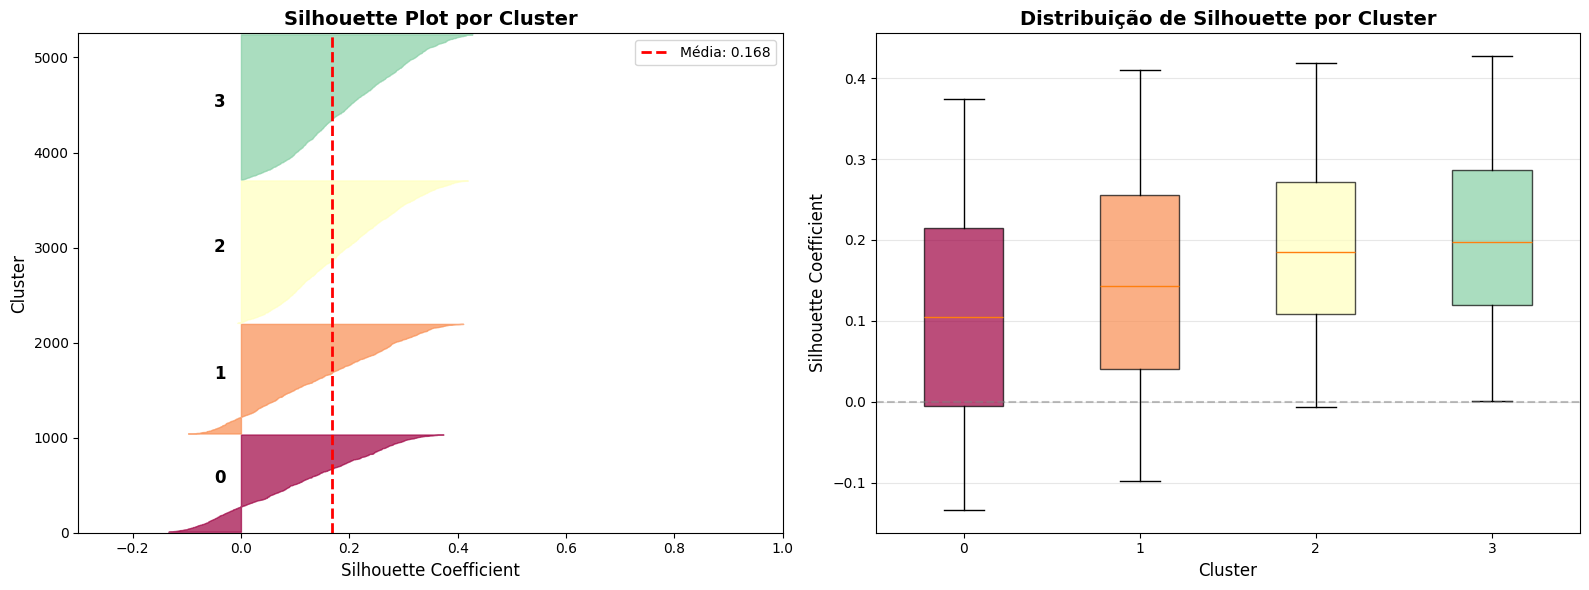


📊 ESTATÍSTICAS DE SILHOUETTE POR CLUSTER:

Cluster 0:
   Média:    0.107
   Mediana:  0.104
   Desvio:   0.127
   Min/Max: -0.134 /  0.374
   % Positivo: 73.7%

Cluster 1:
   Média:    0.147
   Mediana:  0.143
   Desvio:   0.126
   Min/Max: -0.098 /  0.410
   % Positivo: 84.7%

Cluster 2:
   Média:    0.191
   Mediana:  0.185
   Desvio:   0.102
   Min/Max: -0.007 /  0.419
   % Positivo: 99.4%

Cluster 3:
   Média:    0.202
   Mediana:  0.197
   Desvio:   0.103
   Min/Max:  0.001 /  0.427
   % Positivo: 100.0%



In [32]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 21: Análise de silhouette por cluster
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("📐 ANÁLISE DE SILHOUETTE POR CLUSTER")
print("="*80)
print()

# Calcular silhouette individual
silhouette_vals = silhouette_samples(X_analysis, labels_final)
df_analysis['silhouette'] = silhouette_vals

print("💡 Silhouette Score mede quão bem cada ponto está atribuído ao seu cluster")
print("   Valores: -1 (muito mal) a +1 (muito bem)")
print()

# Análise por cluster
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Silhouette plot
ax1 = axes[0]
y_lower = 10

for cluster_id in unique_clusters:
    cluster_silhouette_vals = silhouette_vals[labels_final == cluster_id]
    cluster_silhouette_vals.sort()
    
    size_cluster = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster
    
    color = plt.cm.Spectral(float(cluster_id) / len(unique_clusters))
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette_vals,
        facecolor=color,
        edgecolor=color,
        alpha=0.7
    )
    
    ax1.text(-0.05, y_lower + 0.5 * size_cluster, str(cluster_id), fontsize=12, fontweight='bold')
    y_lower = y_upper + 10

ax1.set_title('Silhouette Plot por Cluster', fontsize=14, fontweight='bold')
ax1.set_xlabel('Silhouette Coefficient', fontsize=12)
ax1.set_ylabel('Cluster', fontsize=12)

# Linha vertical para média
ax1.axvline(x=silhouette_score(X_analysis, labels_final), color="red", linestyle="--", linewidth=2, label=f'Média: {silhouette_score(X_analysis, labels_final):.3f}')
ax1.legend()
ax1.set_xlim([-0.3, 1])
ax1.set_ylim([0, len(labels_final) + (len(unique_clusters) + 1) * 10])

# Plot 2: Box plot
ax2 = axes[1]
silhouette_by_cluster = [silhouette_vals[labels_final == c] for c in unique_clusters]
bp = ax2.boxplot(silhouette_by_cluster, labels=unique_clusters, patch_artist=True)

for patch, cluster_id in zip(bp['boxes'], unique_clusters):
    color = plt.cm.Spectral(float(cluster_id) / len(unique_clusters))
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_title('Distribuição de Silhouette por Cluster', fontsize=14, fontweight='bold')
ax2.set_xlabel('Cluster', fontsize=12)
ax2.set_ylabel('Silhouette Coefficient', fontsize=12)
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

output_file = figures_dir / '34_silhouette_detalhado.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico de silhouette salvo: {output_file}")
plt.show()

print()
print("📊 ESTATÍSTICAS DE SILHOUETTE POR CLUSTER:")
print()

for cluster_id in unique_clusters:
    cluster_sil = silhouette_vals[labels_final == cluster_id]
    
    mean_sil = cluster_sil.mean()
    median_sil = np.median(cluster_sil)
    std_sil = cluster_sil.std()
    min_sil = cluster_sil.min()
    max_sil = cluster_sil.max()
    
    # Porcentagem de pontos com silhouette positivo
    pct_positive = (cluster_sil > 0).sum() / len(cluster_sil) * 100
    
    print(f"Cluster {cluster_id}:")
    print(f"   Média:   {mean_sil:6.3f}")
    print(f"   Mediana: {median_sil:6.3f}")
    print(f"   Desvio:  {std_sil:6.3f}")
    print(f"   Min/Max: {min_sil:6.3f} / {max_sil:6.3f}")
    print(f"   % Positivo: {pct_positive:.1f}%")
    print()

🔀 ANÁLISE DE SEPARABILIDADE ENTRE CLUSTERS

📏 MATRIZ DE DISTÂNCIAS ENTRE CENTRÓIDES:



,C0,C1,C2,C3
C0,0.000,3.421,2.395,2.353
C1,3.421,0.000,2.179,2.272
C2,2.395,2.179,0.000,1.798
C3,2.353,2.272,1.798,0.000



✅ Matriz de distâncias salva: ..\outputs\figures\35_distancias_centroides.png


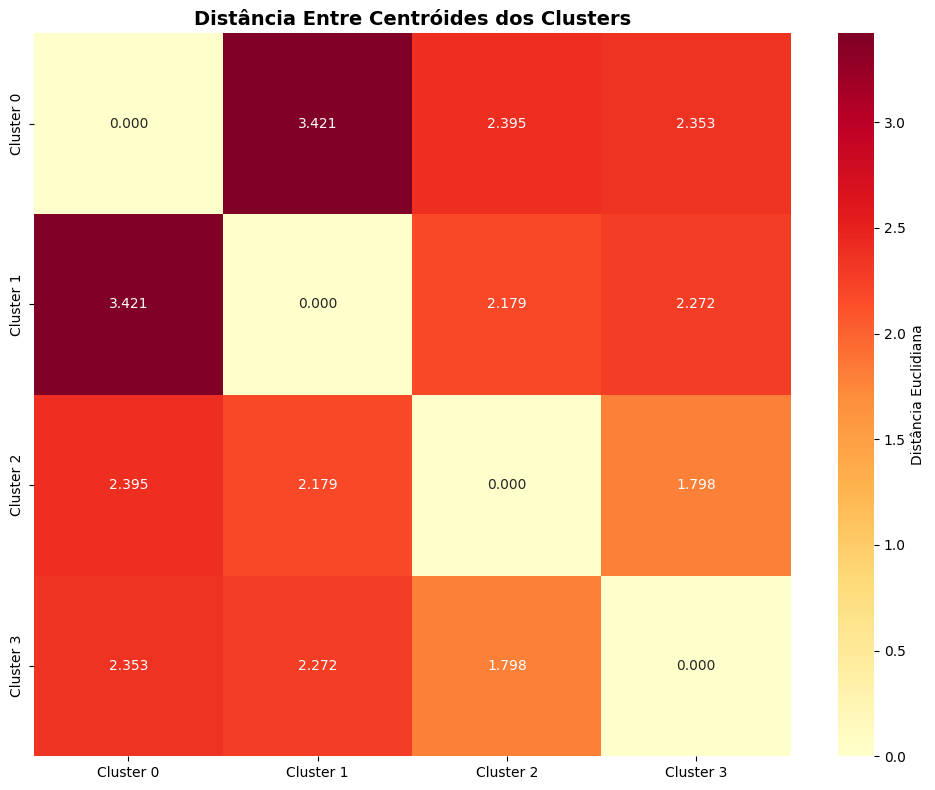


🔴 CLUSTERS MAIS PRÓXIMOS:
   Cluster 2 ↔ Cluster 3: 1.798
   ⚠️  Estes clusters podem ter sobreposição!

🟢 CLUSTERS MAIS DISTANTES:
   Cluster 0 ↔ Cluster 1: 3.421
   ✅ Estes clusters são bem distintos!



In [33]:
#═══════════════════════════════════════════════════════════════════════════
# CÉLULA 22: Análise de separabilidade entre clusters
#═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("🔀 ANÁLISE DE SEPARABILIDADE ENTRE CLUSTERS")
print("="*80)
print()
from sklearn.metrics.pairwise import pairwise_distances

#Calcular centróides
centroids = []
for cluster_id in unique_clusters:
    cluster_points = X_analysis[labels_final == cluster_id]
    centroid = cluster_points.mean(axis=0)
    centroids.append(centroid)
    
centroids = np.array(centroids)

#Calcular distâncias entre centróides
centroid_distances = pairwise_distances(centroids, metric='euclidean')
print("📏 MATRIZ DE DISTÂNCIAS ENTRE CENTRÓIDES:")
print()

#Criar DataFrame para visualização
dist_df = pd.DataFrame(
centroid_distances,
index=[f'C{c}' for c in unique_clusters],
columns=[f'C{c}' for c in unique_clusters]
)
display(dist_df.round(3))
print()

#Visualizar matriz de distâncias
plt.figure(figsize=(10, 8))
sns.heatmap(
centroid_distances,
annot=True,
fmt='.3f',
cmap='YlOrRd',
xticklabels=[f'Cluster {c}' for c in unique_clusters],
yticklabels=[f'Cluster {c}' for c in unique_clusters],
cbar_kws={'label': 'Distância Euclidiana'}
)
plt.title('Distância Entre Centróides dos Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
output_file = figures_dir / '35_distancias_centroides.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Matriz de distâncias salva: {output_file}")
plt.show()
print()

#Identificar pares mais próximos e mais distantes
mask = np.triu(np.ones_like(centroid_distances, dtype=bool), k=1)
distances_upper = centroid_distances.copy()
distances_upper[~mask] = np.nan
min_dist_idx = np.nanargmin(distances_upper)
min_dist_i, min_dist_j = np.unravel_index(min_dist_idx, distances_upper.shape)
max_dist_idx = np.nanargmax(distances_upper)
max_dist_i, max_dist_j = np.unravel_index(max_dist_idx, distances_upper.shape)
print(f"🔴 CLUSTERS MAIS PRÓXIMOS:")
print(f"   Cluster {unique_clusters[min_dist_i]} ↔ Cluster {unique_clusters[min_dist_j]}: {centroid_distances[min_dist_i, min_dist_j]:.3f}")
print(f"   ⚠️  Estes clusters podem ter sobreposição!")
print()
print(f"🟢 CLUSTERS MAIS DISTANTES:")
print(f"   Cluster {unique_clusters[max_dist_i]} ↔ Cluster {unique_clusters[max_dist_j]}: {centroid_distances[max_dist_i, max_dist_j]:.3f}")
print(f"   ✅ Estes clusters são bem distintos!")
print()


🎯 FEATURES MAIS DISCRIMINATIVAS ENTRE CLUSTERS

💡 Usando ANOVA (F-statistic) para identificar features que mais separam os clusters

📊 RANKING DE FEATURES POR PODER DISCRIMINATIVO:



,Feature,F-Statistic,P-Value
0,PC1,2946.979995,0.000000
2,PC3,1500.074037,0.000000
1,PC2,748.899213,0.000000
3,PC4,8.270680,0.000017



✅ Gráfico de importância salvo: ..\outputs\figures\36_feature_importance.png


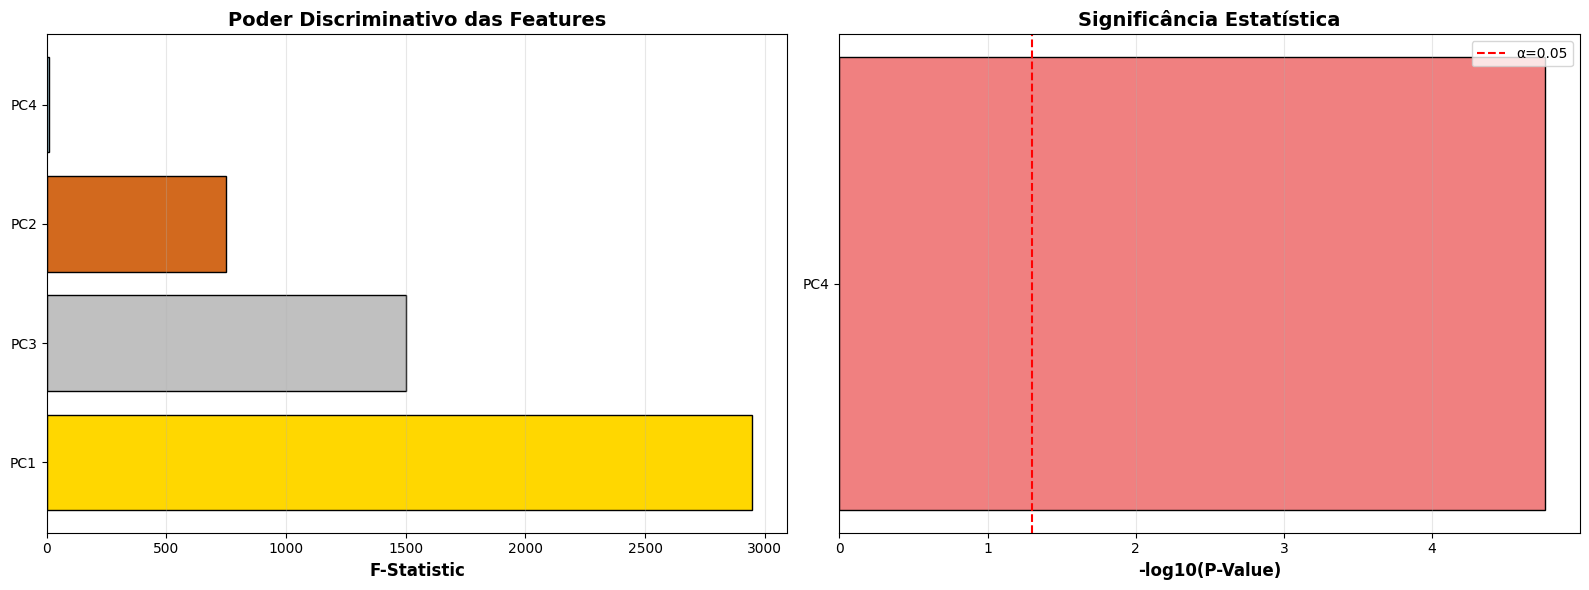


🥇 TOP 3 FEATURES MAIS DISCRIMINATIVAS:
   PC1                                      F=2,946.98  p=0.00e+00

   PC3                                      F=1,500.07  p=0.00e+00

   PC2                                      F=  748.90  p=0.00e+00



In [34]:
#═══════════════════════════════════════════════════════════════════════════
# CÉLULA 23: Análise de features mais discriminativas
#═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("🎯 FEATURES MAIS DISCRIMINATIVAS ENTRE CLUSTERS")
print("="*80)
print()
print("💡 Usando ANOVA (F-statistic) para identificar features que mais separam os clusters")
print()

from sklearn.feature_selection import f_classif

# Definir dados para ANOVA
if winner == 'KMeans + PCA':
    # Para PCA, usar os componentes
    feature_names_analysis = [f'PC{i+1}' for i in range(X_pca.shape[1])]
    X_for_anova = X_pca
else:
    feature_names_analysis = selected_features
    X_for_anova = X

# Calcular F-statistic e p-values
f_stats, p_values = f_classif(X_for_anova, labels_final)

# Criar DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names_analysis,
    'F-Statistic': f_stats,
    'P-Value': p_values
}).sort_values('F-Statistic', ascending=False)

print("📊 RANKING DE FEATURES POR PODER DISCRIMINATIVO:")
print()
display(feature_importance)
print()

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: F-Statistic
ax1 = axes[0]
colors_importance = [
    'gold' if i == 0 else 'silver' if i == 1 else 'chocolate' if i == 2 else 'lightblue'
    for i in range(len(feature_importance))
]
ax1.barh(feature_importance['Feature'], feature_importance['F-Statistic'],
         color=colors_importance, edgecolor='black')
ax1.set_xlabel('F-Statistic', fontsize=12, fontweight='bold')
ax1.set_title('Poder Discriminativo das Features', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: P-Values (escala log)
ax2 = axes[1]
ax2.barh(feature_importance['Feature'], -np.log10(feature_importance['P-Value']),
         color='lightcoral', edgecolor='black')
ax2.set_xlabel('-log10(P-Value)', fontsize=12, fontweight='bold')
ax2.set_title('Significância Estatística', fontsize=14, fontweight='bold')
ax2.axvline(x=-np.log10(0.05), color='red', linestyle='--', label='α=0.05')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
output_file = figures_dir / '36_feature_importance.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico de importância salvo: {output_file}")
plt.show()
print()

# Top 3 features
print("🥇 TOP 3 FEATURES MAIS DISCRIMINATIVAS:")
for _, row in feature_importance.head(3).iterrows():
    print(f"   {row['Feature']:<40} F={row['F-Statistic']:8,.2f}  p={row['P-Value']:.2e}")
    print()


In [35]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 24: Visualização 3D dos clusters
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("🌐 VISUALIZAÇÃO 3D DOS CLUSTERS")
print("="*80)
print()

# Importações necessárias
from sklearn.decomposition import PCA
import plotly.graph_objects as go

# Aplicar PCA para visualização 3D (se ainda não estiver em PCA)
if winner == 'KMeans + PCA' and X_pca.shape[1] >= 3:
    X_3d = X_pca[:, :3]
    pc_labels = ['PC1', 'PC2', 'PC3']
    var_explained_3d = None
else:
    pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
    X_3d = pca_3d.fit_transform(X)
    var_explained_3d = pca_3d.explained_variance_ratio_
    pc_labels = [
        f"PC1 ({var_explained_3d[0]*100:.1f}%)",
        f"PC2 ({var_explained_3d[1]*100:.1f}%)",
        f"PC3 ({var_explained_3d[2]*100:.1f}%)"
    ]
    print(f"📊 Variância explicada por 3 componentes: {var_explained_3d.sum()*100:.2f}%")
    print()

# Criar DataFrame para Plotly
df_3d = pd.DataFrame({
    'PC1': X_3d[:, 0],
    'PC2': X_3d[:, 1],
    'PC3': X_3d[:, 2],
    'Cluster': labels_final,
    'Municipio': df['nome_municipio'],
    'UF': df['uf'],
    'Populacao': df['populacao_original']
})

# Filtrar ruído se existir
df_3d_no_noise = df_3d[df_3d['Cluster'] != -1].copy()
df_3d_noise = df_3d[df_3d['Cluster'] == -1].copy() if (-1 in df_3d['Cluster'].unique()) else None

# Plot interativo com Plotly
fig = go.Figure()

# Adicionar clusters
for cluster_id in unique_clusters:
    if cluster_id == -1:
        continue

    cluster_data = df_3d_no_noise[df_3d_no_noise['Cluster'] == cluster_id]

    fig.add_trace(go.Scatter3d(
        x=cluster_data['PC1'],
        y=cluster_data['PC2'],
        z=cluster_data['PC3'],
        mode='markers',
        name=f'Cluster {cluster_id}',
        marker=dict(size=3, opacity=0.7),
        text=cluster_data.apply(
            lambda row: f"{row['Municipio']}, {row['UF']}<br>Pop: {row['Populacao']:,.0f}",
            axis=1
        ),
        hovertemplate=(
            '<b>%{text}</b><br>'
            'PC1: %{x:.2f}<br>'
            'PC2: %{y:.2f}<br>'
            'PC3: %{z:.2f}'
            '<extra></extra>'
        )
    ))

# Adicionar ruído se existir
if df_3d_noise is not None and len(df_3d_noise) > 0:
    fig.add_trace(go.Scatter3d(
        x=df_3d_noise['PC1'],
        y=df_3d_noise['PC2'],
        z=df_3d_noise['PC3'],
        mode='markers',
        name='Ruído',
        marker=dict(size=2, color='gray', opacity=0.3),
        text=df_3d_noise.apply(
            lambda row: f"{row['Municipio']}, {row['UF']}<br>Pop: {row['Populacao']:,.0f}",
            axis=1
        ),
        hovertemplate=(
            '<b>%{text}</b><br>'
            'PC1: %{x:.2f}<br>'
            'PC2: %{y:.2f}<br>'
            'PC3: %{z:.2f}'
            '<extra></extra>'
        )
    ))

fig.update_layout(
    title=f'Visualização 3D dos Clusters - {winner}',
    scene=dict(
        xaxis_title=pc_labels[0],
        yaxis_title=pc_labels[1],
        zaxis_title=pc_labels[2]
    ),
    height=800,
    showlegend=True
)

output_html = figures_dir / '37_clusters_3d.html'
fig.write_html(output_html)
print(f"✅ Visualização 3D salva: {output_html}")

fig.show()
print()


🌐 VISUALIZAÇÃO 3D DOS CLUSTERS

✅ Visualização 3D salva: ..\outputs\figures\37_clusters_3d.html


In [36]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 25: Salvar dataset final com clusters
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("💾 SALVANDO DATASET FINAL COM CLUSTERS")
print("="*80)
print()

# Preparar dataset final
df_final = df.copy()
df_final['cluster_final'] = labels_final
df_final['silhouette_score'] = silhouette_vals

# Adicionar label descritivo para cada cluster (você pode customizar depois)
# Cria labels automaticamente para todos os clusters encontrados
clusters_encontrados = sorted(pd.Series(labels_final).unique())

cluster_labels = {c: f"Cluster {c}" for c in clusters_encontrados if c != -1}
if -1 in clusters_encontrados:
    cluster_labels[-1] = "Ruído"

df_final['cluster_nome'] = df_final['cluster_final'].map(cluster_labels)

# Salvar dataset completo
output_path = results_dir / 'municipios_clusterizados_final.csv'
df_final.to_csv(output_path, index=False)

print(f"✅ Dataset final salvo: {output_path}")
print(f"   {len(df_final):,} municípios")
print(f"   {len(df_final.columns)} colunas")
print()

# Salvar também versão simplificada
cols_simple = [
    'codigo_ibge', 'nome_municipio', 'uf', 'regiao', 'populacao_estimada',
    'cluster_final', 'cluster_nome', 'silhouette_score'
]

# Garantir que só pega colunas que existem (evita erro se alguma não estiver no df)
cols_simple = [c for c in cols_simple if c in df_final.columns]

df_simple = df_final[cols_simple].copy()

output_simple = results_dir / 'municipios_clusters_simples.csv'
df_simple.to_csv(output_simple, index=False)

print(f"✅ Versão simplificada salva: {output_simple}")
print()


💾 SALVANDO DATASET FINAL COM CLUSTERS

✅ Dataset final salvo: ..\outputs\results\municipios_clusterizados_final.csv
   5,204 municípios
   21 colunas

✅ Versão simplificada salva: ..\outputs\results\municipios_clusters_simples.csv



In [37]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 26: Relatório executivo em texto
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("📄 GERANDO RELATÓRIO EXECUTIVO")
print("="*80)
print()

report_lines = []
report_lines.append("="*80)
report_lines.append("RELATÓRIO EXECUTIVO - CLUSTERIZAÇÃO DE MUNICÍPIOS BRASILEIROS")
report_lines.append("="*80)
report_lines.append("")
report_lines.append(f"Data da Análise: {pd.Timestamp.now().strftime('%d/%m/%Y %H:%M')}")
report_lines.append("")

report_lines.append("─" * 80)
report_lines.append("1. RESUMO EXECUTIVO")
report_lines.append("─" * 80)
report_lines.append("")
report_lines.append(f"• Total de municípios analisados: {len(df):,}")
report_lines.append(f"• Número de features utilizadas: {len(selected_features)}")
report_lines.append(f"• Algoritmo selecionado: {winner}")
report_lines.append(f"• Número de clusters identificados: {len(unique_clusters)}")
report_lines.append("")

winner_row = comparison_clean[comparison_clean['Algoritmo'] == winner].iloc[0]
report_lines.append("Métricas do modelo vencedor:")
report_lines.append(f"  - Silhouette Score: {winner_row['Silhouette']:.4f}")
report_lines.append(f"  - Davies-Bouldin Index: {winner_row['Davies-Bouldin']:.4f}")
report_lines.append(f"  - Calinski-Harabasz Score: {winner_row['Calinski-Harabasz']:.2f}")
report_lines.append(f"  - Tempo de execução: {winner_row['Tempo (s)']:.2f}s")
report_lines.append("")

report_lines.append("─" * 80)
report_lines.append("2. METODOLOGIA")
report_lines.append("─" * 80)
report_lines.append("")
report_lines.append("Algoritmos testados:")

for idx, row in comparison_clean.iterrows():
    report_lines.append(f"  {idx+1}. {row['Algoritmo']}")

report_lines.append("")
report_lines.append("Features utilizadas:")

for i, feat in enumerate(selected_features, 1):
    report_lines.append(f"  {i}. {feat}")

report_lines.append("")

report_lines.append("─" * 80)
report_lines.append("3. PERFIL DOS CLUSTERS")
report_lines.append("─" * 80)
report_lines.append("")

for cluster_id in unique_clusters:
    cluster_data = df_analysis[df_analysis['cluster'] == cluster_id]
    n_mun = len(cluster_data)

    if n_mun == 0:
        report_lines.append(f"CLUSTER {cluster_id}")
        report_lines.append("  • Tamanho: 0 municípios (0.0%)")
        report_lines.append("")
        continue

    pct = n_mun / len(df_analysis) * 100
    report_lines.append(f"CLUSTER {cluster_id}")
    report_lines.append(f"  • Tamanho: {n_mun:,} municípios ({pct:.1f}%)")

    # Região predominante
    main_region = cluster_data['regiao'].value_counts().index[0]
    region_pct = cluster_data['regiao'].value_counts().values[0] / n_mun * 100
    report_lines.append(f"  • Região predominante: {main_region} ({region_pct:.1f}%)")

    # Características (top 3 features)
    report_lines.append("  • Características principais:")
    for feat in selected_features[:3]:
        mean_val = cluster_data[feat].mean()
        overall_mean = df_analysis[feat].mean()
        diff = mean_val - overall_mean

        if abs(diff) > 0.3:
            indicator = "ALTO" if diff > 0 else "BAIXO"
            report_lines.append(f"    - {feat}: {indicator}")

    report_lines.append("")

report_lines.append("─" * 80)
report_lines.append("4. RECOMENDAÇÕES")
report_lines.append("─" * 80)
report_lines.append("")
report_lines.append("Com base na análise realizada, recomenda-se:")
report_lines.append("")
report_lines.append("1. Validação dos clusters com especialistas de domínio")
report_lines.append("2. Atribuição de nomes descritivos para cada cluster")
report_lines.append("3. Análise aprofundada dos municípios com baixo silhouette score")

if -1 in df_analysis['cluster'].unique():
    n_noise = (df_analysis['cluster'] == -1).sum()
    report_lines.append(f"4. Investigação dos {n_noise:,} municípios classificados como ruído")
    report_lines.append("5. Aplicação dos clusters em análises subsequentes")
else:
    report_lines.append("4. Aplicação dos clusters em análises subsequentes")

report_lines.append("")
report_lines.append("─" * 80)
report_lines.append("5. ARQUIVOS GERADOS")
report_lines.append("─" * 80)
report_lines.append("")
report_lines.append(f"• {output_path.name}")
report_lines.append(f"• {output_simple.name}")
report_lines.append("• Múltiplas visualizações (.png e .html)")
report_lines.append("• Modelos treinados salvos para reprodução")
report_lines.append("")
report_lines.append("="*80)
report_lines.append("FIM DO RELATÓRIO")
report_lines.append("="*80)

# Salvar relatório
report_text = "\n".join(report_lines)
report_path = results_dir / 'relatorio_clusterizacao.txt'

with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_text)

print(f"✅ Relatório executivo salvo: {report_path}")
print()

# Exibir relatório
print(report_text)


📄 GERANDO RELATÓRIO EXECUTIVO

✅ Relatório executivo salvo: ..\outputs\results\relatorio_clusterizacao.txt

RELATÓRIO EXECUTIVO - CLUSTERIZAÇÃO DE MUNICÍPIOS BRASILEIROS

Data da Análise: 25/01/2026 14:06

────────────────────────────────────────────────────────────────────────────────
1. RESUMO EXECUTIVO
────────────────────────────────────────────────────────────────────────────────

• Total de municípios analisados: 5,204
• Número de features utilizadas: 7
• Algoritmo selecionado: KMeans + PCA
• Número de clusters identificados: 4

Métricas do modelo vencedor:
  - Silhouette Score: 0.1681
  - Davies-Bouldin Index: 1.5545
  - Calinski-Harabasz Score: 1158.24
  - Tempo de execução: 0.71s

────────────────────────────────────────────────────────────────────────────────
2. METODOLOGIA
────────────────────────────────────────────────────────────────────────────────

Algoritmos testados:
  1. KMeans
  2. KMeans + PCA
  3. Agglomerative (K=4)
  4. GMM (K=2)

Features utilizadas:
  1. log_p

In [38]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 27: Conclusão e próximos passos
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🎊 ANÁLISE COMPLETA - NOTEBOOK 8 FINALIZADO!")
print("="*80)
print()

print("✅ RESULTADOS OBTIDOS:")
print(f"   • {len(comparison_clean)} algoritmos testados e comparados")
print(f"   • Algoritmo vencedor: {winner}")
print(f"   • {len(unique_clusters)} clusters identificados")
print(f"   • {len(df):,} municípios clusterizados")
print(f"   • Silhouette Score final: {winner_row['Silhouette']:.4f}")
print()

print("📂 ARQUIVOS GERADOS:")
print(f"   ✅ {comparison_df.shape[0]} comparações salvas em CSV")
print(f"   ✅ {len(list(figures_dir.glob('*.png')))} visualizações em PNG")
print(f"   ✅ {len(list(figures_dir.glob('*.html')))} gráficos interativos")
print(f"   ✅ {len(list(models_dir.glob('*.pkl')))} modelos salvos")
print("   ✅ Dataset final com clusters")
print("   ✅ Relatório executivo")
print()

print("🎯 PRÓXIMOS PASSOS SUGERIDOS:")
print()
print("1️⃣  NOTEBOOK 9: Nomeação e Interpretação dos Clusters")
print("   • Atribuir nomes descritivos para cada cluster")
print("   • Criar personas/arquétipos de municípios")
print("   • Análise qualitativa aprofundada")
print()
print("2️⃣  NOTEBOOK 10: Validação e Aplicação")
print("   • Validar clusters com dados externos")
print("   • Aplicar clusters em casos de uso")
print("   • Análise de políticas públicas por cluster")
print()
print("3️⃣  NOTEBOOK 11: Visualizações Avançadas")
print("   • Mapas coroplético por cluster")
print("   • Dashboard interativo")
print("   • Análises geoespaciais")
print()

print("="*80)
print("💡 INSIGHTS PRINCIPAIS:")
print("="*80)
print()

# Calcular alguns insights
best_cluster = df_analysis.groupby('cluster')['silhouette'].mean().idxmax()
worst_cluster = df_analysis.groupby('cluster')['silhouette'].mean().idxmin()

best_mean = df_analysis.loc[df_analysis['cluster'] == best_cluster, 'silhouette'].mean()
worst_mean = df_analysis.loc[df_analysis['cluster'] == worst_cluster, 'silhouette'].mean()

print(f"✨ Cluster mais coeso: Cluster {best_cluster}")
print(f"   (Maior silhouette médio: {best_mean:.3f})")
print()

print(f"⚠️  Cluster com mais sobreposição: Cluster {worst_cluster}")
print(f"   (Menor silhouette médio: {worst_mean:.3f})")
print()

# Feature mais discriminativa
top_feature = feature_importance.iloc[0]
print(f"🎯 Feature mais discriminativa: {top_feature['Feature']}")
print(f"   (F-statistic: {top_feature['F-Statistic']:.2f})")
print()

print("="*80)
print("🙏 OBRIGADO POR USAR ESTE NOTEBOOK!")
print("="*80)
print()
print("📧 Para dúvidas ou sugestões, consulte a documentação do projeto")
print("🔗 GitHub: [adicionar link do repositório]")
print()



🎊 ANÁLISE COMPLETA - NOTEBOOK 8 FINALIZADO!

✅ RESULTADOS OBTIDOS:
   • 4 algoritmos testados e comparados
   • Algoritmo vencedor: KMeans + PCA
   • 4 clusters identificados
   • 5,204 municípios clusterizados
   • Silhouette Score final: 0.1681

📂 ARQUIVOS GERADOS:
   ✅ 6 comparações salvas em CSV
   ✅ 21 visualizações em PNG
   ✅ 16 gráficos interativos
   ✅ 8 modelos salvos
   ✅ Dataset final com clusters
   ✅ Relatório executivo

🎯 PRÓXIMOS PASSOS SUGERIDOS:

1️⃣  NOTEBOOK 9: Nomeação e Interpretação dos Clusters
   • Atribuir nomes descritivos para cada cluster
   • Criar personas/arquétipos de municípios
   • Análise qualitativa aprofundada

2️⃣  NOTEBOOK 10: Validação e Aplicação
   • Validar clusters com dados externos
   • Aplicar clusters em casos de uso
   • Análise de políticas públicas por cluster

3️⃣  NOTEBOOK 11: Visualizações Avançadas
   • Mapas coroplético por cluster
   • Dashboard interativo
   • Análises geoespaciais

💡 INSIGHTS PRINCIPAIS:

✨ Cluster mais coeso